# 05. Ablation Study

## 0. Setup

In [28]:
import csv
import random
import re
import json
import time
from pathlib import Path
from collections import defaultdict

import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts, CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.utils.checkpoint import checkpoint  
from sklearn.metrics import f1_score, roc_auc_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

MANIFEST = Path('~/Desktop/convscript/Code/Manifest/manifests/master_manifest.csv').expanduser()
ROOT     = Path('~/Desktop/Thesis/TR-6').expanduser() 
GAS_NORM = Path('~/Desktop/convscript/Code/Manifest/GasNorm/gas_norm_stats.json').expanduser()
RUNS     = Path('~/Desktop/convscript/runs').expanduser()

DEVICE = (
    'mps'  if torch.backends.mps.is_available() else
    'cuda' if torch.cuda.is_available()          else
    'cpu'
)
print(f'Device: {DEVICE}')

from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import math

ABLATION_OUT = RUNS / "04_fusion_model"
ABLATION_OUT.mkdir(parents=True, exist_ok=True)


Device: mps


In [29]:
FRUIT_LIST   = ['Banana', 'Carrot', 'Guava', 'Indian_Gooseberry', 'Mango', 'Tomato']
FRUIT_TO_IDX = {f: i for i, f in enumerate(FRUIT_LIST)}
FRUIT_COLORS = {'Banana':'#F5C518','Carrot':'#FF6B35','Guava':'#7BC67E',
                'Indian_Gooseberry':'#9B59B6','Mango':'#FF8C00','Tomato':'#E74C3C'}
SESSION_TO_IDX = {'morning':0,'afternoon':1,'evening':2}
LABEL_TO_IDX   = {'not_spoiled':0,'spoiled':1}
IMAGE_SIZE     = 224
IMAGENET_MEAN  = [0.485, 0.456, 0.406]
IMAGENET_STD   = [0.229, 0.224, 0.225]
SESSION_HOUR_BUCKETS = {'morning':(5,11),'afternoon':(12,16),'evening':(16,19)}
IR_PATTERN   = re.compile(r'(\d{8})_(\d{6})_([\d.]+)C_([\d.]+)C\.jpg$', re.IGNORECASE)
SRGB_PATTERN = re.compile(r'^(\d{8})_(\d{6})[^/]*\.jpg$', re.IGNORECASE)
NUM_FRUITS   = len(FRUIT_TO_IDX)
ABLATIONS    = ['no_cross_attn','no_dropout','no_fruit_emb','no_recon','no_session_idx','no_gas_norm']
THRESHOLDS_TO_SWEEP = [t/100 for t in range(10, 91)]

SUBSETS = [
    {'name':'RGB only',       'rgb':True,  'ir':False,'gas':False},
    {'name':'IR only',        'rgb':False, 'ir':True, 'gas':False},
    {'name':'Gas only',       'rgb':False, 'ir':False,'gas':True},
    {'name':'RGB + IR',       'rgb':True,  'ir':True, 'gas':False},
    {'name':'RGB + Gas',      'rgb':True,  'ir':False,'gas':True},
    {'name':'IR + Gas',       'rgb':False, 'ir':True, 'gas':True},
    {'name':'All modalities', 'rgb':True,  'ir':True, 'gas':True},
]
N_AVAILABLE = {'RGB only':1,'IR only':1,'Gas only':1,
               'RGB + IR':2,'RGB + Gas':2,'IR + Gas':2,'All modalities':3}

def safe_float(val, default=0.0):
    try: return float(val)
    except: return default

def hour_to_session(hour):
    for name,(lo,hi) in SESSION_HOUR_BUCKETS.items():
        if lo<=hour<hi: return name
    return 'unknown'

def find_ir_folder(base):
    for name in ['IR_fusion_images','IR_Fusion_images','ir_fusion_images']:
        p=base/name
        if p.exists(): return p
    return base/'IR_fusion_images'

def group_images_by_session(folder, pattern):
    result=defaultdict(lambda:defaultdict(list))
    if not folder.exists(): return {}
    for f in sorted(folder.iterdir()):
        m=pattern.search(f.name)
        if not m: continue
        session=hour_to_session(int(m.group(2)[:2]))
        if session!='unknown': result[m.group(1)][session].append(f)
    return dict(result)

print('Constants ready.')


Constants ready.


In [30]:
def get_rgb_transform(train: bool):
    if train:
        return transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(), transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


def get_ir_transform(train: bool):
    if train:
        return transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(), transforms.RandomRotation(15),
            transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


In [31]:
class TrimodalDataset(Dataset):
    def __init__(self,manifest_path,root,train=True,modality_dropout_prob=0.3,
                 exclude_flagged=True,split=None,gas_norm_stats_path=None,
                 cache_images=True,shared_pixel_cache=None,gas_only=False):
        self.root=Path(root);self.train=train;self.modality_dropout_prob=modality_dropout_prob
        self.rgb_transform=get_rgb_transform(train);self.ir_transform=get_ir_transform(train)
        self.gas_norm_stats=None
        if gas_norm_stats_path:
            with open(gas_norm_stats_path) as f: self.gas_norm_stats=json.load(f)['stats']
            print(f'Gas norm stats loaded from {gas_norm_stats_path}')
        with open(manifest_path,newline='') as f: all_rows=list(csv.DictReader(f))
        if exclude_flagged: all_rows=[r for r in all_rows if r.get('exclude','').strip().lower()!='true']
        if split: all_rows=[r for r in all_rows if r.get('split','').strip().lower()==split.lower()]
        self.samples=[];self._build_samples(all_rows)
        self.gas_only=gas_only;self._image_cache={}
        if not gas_only: self._build_image_index()
        self._pixel_cache={}
        if not gas_only:
            if shared_pixel_cache is not None:
                self._pixel_cache=shared_pixel_cache
                print(f'  Using shared image cache ({len(self._pixel_cache)} images).',flush=True)
            elif cache_images: self._warmup_pixel_cache()
        print(f'TrimodalDataset: {len(self.samples)} sessions ({"train" if train else "val/test"}, split={split})')

    def _build_samples(self,rows):
        for row in rows:
            fruit=row['fruit'];label=row['label'];date_str=row['actual_date']
            global_day=int(row['corrected_day_index'])
            days_until=safe_float(row.get('days_until_spoilage',''),default=-1.0)
            for session in ['morning','afternoon','evening']:
                si=SESSION_TO_IDX[session]
                ir_avail=safe_float(row.get(f'ir_{session}_count',0))>0
                ir_tmin=safe_float(row.get(f'ir_{session}_tmin',''),0.0)
                ir_tmax=safe_float(row.get(f'ir_{session}_tmax',''),0.0)
                ir_trange=safe_float(row.get(f'ir_{session}_trange',''),0.0)
                srgb_avail=safe_float(row.get(f'srgb_{session}_count',0))>0
                gas_avail=row.get(f'methane_{session}_present','').strip().upper()=='TRUE'
                mean_ppm=safe_float(row.get(f'methane_{session}_ppm',''),0.0)
                std_ppm=safe_float(row.get(f'methane_{session}_std',''),0.0)
                left_ppm=safe_float(row.get(f'methane_{session}_left',''),0.0)
                right_ppm=safe_float(row.get(f'methane_{session}_right',''),0.0)
                if not ir_avail and not srgb_avail and not gas_avail: continue
                self.samples.append({'fruit':fruit,'label':label,'actual_date':date_str,
                    'corrected_day_index':global_day,'session':session,'session_idx':si,
                    'fruit_idx':FRUIT_TO_IDX.get(fruit,0),'label_idx':LABEL_TO_IDX.get(label,0),
                    'days_until_spoilage':days_until,'ir_tmin':ir_tmin,'ir_tmax':ir_tmax,
                    'ir_trange':ir_trange,'gas_mean':mean_ppm,'gas_std':std_ppm,
                    'gas_left':left_ppm,'gas_right':right_ppm,'gas_asym':abs(left_ppm-right_ppm),
                    'rgb_available':srgb_avail,'ir_available':ir_avail,'gas_available':gas_avail})

    def _build_image_index(self):
        label_map={'not_spoiled':'Not_spoiled','spoiled':'Spoiled'}
        for fruit in FRUIT_LIST:
            for lk,lf in label_map.items():
                base=self.root/'Classified'/fruit/lf
                for d,ss in group_images_by_session(base/'sRGB_images',SRGB_PATTERN).items():
                    for s,ps in ss.items():
                        self._image_cache.setdefault((fruit,lk,d,s),{'rgb':[],'ir':[]})['rgb']=ps
                for d,ss in group_images_by_session(find_ir_folder(base),IR_PATTERN).items():
                    for s,ps in ss.items():
                        self._image_cache.setdefault((fruit,lk,d,s),{'rgb':[],'ir':[]})['ir']=ps
        banana_ir=group_images_by_session(find_ir_folder(self.root/'Normal'/'Banana'),IR_PATTERN)
        spoiled_dates={date for (fr,lb,date,_) in self._image_cache if fr=='Banana' and lb=='spoiled'}
        for d,ss in banana_ir.items():
            if d in spoiled_dates:
                for s,ps in ss.items():
                    key=('Banana','spoiled',d,s)
                    self._image_cache.setdefault(key,{'rgb':[],'ir':[]})
                    if not self._image_cache[key].get('ir'): self._image_cache[key]['ir']=ps

    def _load_cached(self,path,transform):
        cached=self._pixel_cache.get(str(path))
        if cached is not None:
            return transform(Image.fromarray(cached.permute(1,2,0).numpy()))
        return load_image(path,transform)

    def _warmup_pixel_cache(self):
        all_paths=set()
        for v in self._image_cache.values():
            all_paths.update(v.get('rgb',[]));all_paths.update(v.get('ir',[]))
        total=len(all_paths)
        print(f'  Warming up image cache: {total} images...',flush=True)
        for i,path in enumerate(all_paths):
            if str(path) in self._pixel_cache: continue
            try:
                img=self.rgb_transform.transforms[0](Image.open(path).convert('RGB'))
                self._pixel_cache[str(path)]=torch.from_numpy(np.array(img)).permute(2,0,1)
            except: pass
            if (i+1)%500==0 or (i+1)==total:
                mb=sum(t.nbytes for t in self._pixel_cache.values())/(1024**2)
                print(f'  {i+1}/{total} cached  ({mb:.0f} MB used)',flush=True)
        print(f'  Cache ready. {len(self._pixel_cache)} images in RAM.',flush=True)

    def _normalize_gas(self,fruit,session,mean_ppm,std_ppm,left_ppm,right_ppm):
        if self.gas_norm_stats is None: return mean_ppm,std_ppm,left_ppm,right_ppm
        s=self.gas_norm_stats.get(fruit,{}).get(session,{})
        def norm(val,key): st=s.get(key,{'mean':0.,'std':1.}); return (val-st['mean'])/st['std']
        return norm(mean_ppm,'mean_ppm'),norm(std_ppm,'std_ppm'),norm(left_ppm,'left_ppm'),norm(right_ppm,'right_ppm')

    def _apply_dropout(self,rgb_avail,ir_avail,gas_avail):
        if not self.train: return rgb_avail,ir_avail,gas_avail
        while True:
            r=rgb_avail and (random.random()>self.modality_dropout_prob)
            i=ir_avail  and (random.random()>self.modality_dropout_prob)
            g=gas_avail and (random.random()>self.modality_dropout_prob)
            if r or i or g: return r,i,g

    def __len__(self): return len(self.samples)

    def __getitem__(self,idx):
        s=self.samples[idx]
        fruit=s['fruit'];label=s['label'];date_str=s['actual_date']
        session=s['session'];si=s['session_idx']
        rgb_avail,ir_avail,gas_avail=self._apply_dropout(s['rgb_available'],s['ir_available'],s['gas_available'])
        cached=self._image_cache.get((fruit,label,date_str,session),{'rgb':[],'ir':[]})
        if not self.gas_only and rgb_avail and cached['rgb']:
            rgb_tensors=torch.stack([self._load_cached(p,self.rgb_transform) for p in cached['rgb']])
        else: rgb_avail=False;rgb_tensors=torch.zeros(1,3,IMAGE_SIZE,IMAGE_SIZE)
        if not self.gas_only and ir_avail and cached['ir']:
            ir_tensors=torch.stack([self._load_cached(p,self.ir_transform) for p in cached['ir']])
        else: ir_avail=False;ir_tensors=torch.zeros(1,3,IMAGE_SIZE,IMAGE_SIZE)
        ir_scalars=torch.tensor([s['ir_tmin'],s['ir_tmax'],s['ir_trange']],dtype=torch.float32) if ir_avail else torch.zeros(3)
        if gas_avail:
            m,sd,l,r=self._normalize_gas(fruit,session,s['gas_mean'],s['gas_std'],s['gas_left'],s['gas_right'])
            gas=torch.tensor([m,sd,l,r,abs(l-r),float(si)/2.],dtype=torch.float32)
        else: gas=torch.zeros(6)
        return {'rgb_images':rgb_tensors,'ir_images':ir_tensors,'ir_scalars':ir_scalars,'gas':gas,
                'rgb_available':torch.tensor(rgb_avail,dtype=torch.bool),
                'ir_available':torch.tensor(ir_avail,dtype=torch.bool),
                'gas_available':torch.tensor(gas_avail,dtype=torch.bool),
                'fruit_idx':torch.tensor(s['fruit_idx'],dtype=torch.long),
                'session_idx':torch.tensor(si,dtype=torch.long),
                'label':torch.tensor(s['label_idx'],dtype=torch.long),
                'days_until_spoilage':torch.tensor(s['days_until_spoilage'],dtype=torch.float32),
                'fruit':fruit,'actual_date':date_str,'corrected_day_index':s['corrected_day_index']}


class NoSessionIdxDataset(TrimodalDataset):
    def __getitem__(self,idx):
        item=super().__getitem__(idx)
        gas=item['gas'].clone(); gas[5]=0.0; item['gas']=gas
        return item

class NoGasNormDataset(TrimodalDataset):
    def __getitem__(self,idx):
        saved=self.gas_norm_stats; self.gas_norm_stats=None
        item=super().__getitem__(idx); self.gas_norm_stats=saved
        return item


def trimodal_collate(batch):
    return {'rgb_images':[s['rgb_images'] for s in batch],'ir_images':[s['ir_images'] for s in batch],
            'ir_scalars':torch.stack([s['ir_scalars'] for s in batch]),
            'gas':torch.stack([s['gas'] for s in batch]),
            'rgb_available':torch.stack([s['rgb_available'] for s in batch]),
            'ir_available':torch.stack([s['ir_available'] for s in batch]),
            'gas_available':torch.stack([s['gas_available'] for s in batch]),
            'fruit_idx':torch.stack([s['fruit_idx'] for s in batch]),
            'session_idx':torch.stack([s['session_idx'] for s in batch]),
            'label':torch.stack([s['label'] for s in batch]),
            'days_until_spoilage':torch.stack([s['days_until_spoilage'] for s in batch]),
            'fruit':[s['fruit'] for s in batch],'actual_date':[s['actual_date'] for s in batch],
            'corrected_day_index':[s['corrected_day_index'] for s in batch]}

print('Dataset ready.')


Dataset ready.


In [32]:
class DayLevelSequenceDataset(Dataset):
    def __init__(self, manifest_path=MANIFEST, root=ROOT, split="train",
                 gas_norm_stats_path=GAS_NORM, shared_pixel_cache=None):
        base = TrimodalDataset(
            manifest_path, root, train=False, modality_dropout_prob=0.0,
            split=split, gas_norm_stats_path=gas_norm_stats_path, cache_images=True,
            shared_pixel_cache=shared_pixel_cache,
        )
        self._pixel_cache = base._pixel_cache
        print(f"DayLevelSequenceDataset ({split}): wrapping {len(base)} sessions")
        day_groups = defaultdict(list)
        for i in range(len(base)):
            item = base[i]
            key = (item["fruit"], int(item["label"].item()), int(item["corrected_day_index"]))
            day_groups[key].append(item)
        day_entries = {}
        for (fruit, label, day_idx), sessions in day_groups.items():
            sessions.sort(key=lambda s: int(s["session_idx"].item()))
            rgb_img, ir_img = None, None
            for s in sessions:
                if rgb_img is None and bool(s["rgb_available"].item()) and len(s["rgb_images"]) > 0:
                    rgb_img = s["rgb_images"][0]
                if ir_img is None and bool(s["ir_available"].item()) and len(s["ir_images"]) > 0:
                    ir_img = s["ir_images"][0]
            gas_vals = [s["gas"] for s in sessions if bool(s["gas_available"].item())]
            gas_avail = len(gas_vals) > 0
            gas_vec = torch.stack(gas_vals).mean(dim=0) if gas_avail else torch.zeros(6)
            day_entries.setdefault((fruit, label), []).append({
                "day_idx": day_idx, "rgb_img": rgb_img, "ir_img": ir_img,
                "gas_vec": gas_vec, "gas_avail": gas_avail,
                "fruit_idx": sessions[0]["fruit_idx"], "label": sessions[0]["label"],
                "days_until": sessions[0]["days_until_spoilage"],
            })
        self.trajectories = []
        for (fruit, label), days in day_entries.items():
            days.sort(key=lambda d: d["day_idx"])
            last_observed_idx = None
            for d in days:
                d["delta"] = 0.0 if last_observed_idx is None else float(d["day_idx"] - last_observed_idx)
                if d["gas_avail"]:
                    last_observed_idx = d["day_idx"]
            self.trajectories.append({"fruit": fruit, "label": label, "days": days})
        n_days_total = sum(len(t["days"]) for t in self.trajectories)
        print(f"  {len(self.trajectories)} trajectories, {n_days_total} total day-entries")

    def __len__(self):
        return len(self.trajectories)

    def __getitem__(self, idx):
        traj = self.trajectories[idx]["days"]
        T = len(traj)
        blank_rgb = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
        blank_ir  = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
        rgb_seq   = torch.stack([d["rgb_img"] if d["rgb_img"] is not None else blank_rgb for d in traj])
        ir_seq    = torch.stack([d["ir_img"]  if d["ir_img"]  is not None else blank_ir  for d in traj])
        rgb_avail = torch.tensor([d["rgb_img"] is not None for d in traj], dtype=torch.bool)
        ir_avail  = torch.tensor([d["ir_img"]  is not None for d in traj], dtype=torch.bool)
        gas_seq   = torch.stack([d["gas_vec"] for d in traj])
        gas_mask  = torch.tensor([d["gas_avail"] for d in traj], dtype=torch.float32)
        gas_delta = torch.tensor([d["delta"] for d in traj], dtype=torch.float32)
        return {
            "rgb_seq": rgb_seq, "ir_seq": ir_seq, "rgb_avail": rgb_avail, "ir_avail": ir_avail,
            "gas_seq": gas_seq, "gas_mask": gas_mask, "gas_delta": gas_delta, "T": T,
            "fruit_idx": traj[0]["fruit_idx"], "label": traj[-1]["label"],
            "days_until": traj[-1]["days_until"],
        }


def day_sequence_collate(batch):
    max_T = max(b["T"] for b in batch)
    B = len(batch)
    rgb  = torch.zeros(B, max_T, 3, IMAGE_SIZE, IMAGE_SIZE)
    ir   = torch.zeros(B, max_T, 3, IMAGE_SIZE, IMAGE_SIZE)
    rgb_avail = torch.zeros(B, max_T, dtype=torch.bool)
    ir_avail  = torch.zeros(B, max_T, dtype=torch.bool)
    gas  = torch.zeros(B, max_T, 6)
    gas_mask  = torch.zeros(B, max_T)
    gas_delta = torch.zeros(B, max_T)
    pad_mask  = torch.ones(B, max_T, dtype=torch.bool)
    fruit_idx = torch.zeros(B, dtype=torch.long)
    label     = torch.zeros(B, dtype=torch.long)
    days_until = torch.zeros(B, dtype=torch.float32)
    for i, b in enumerate(batch):
        T = b["T"]
        rgb[i, :T] = b["rgb_seq"]; ir[i, :T] = b["ir_seq"]
        rgb_avail[i, :T] = b["rgb_avail"]; ir_avail[i, :T] = b["ir_avail"]
        gas[i, :T] = b["gas_seq"]; gas_mask[i, :T] = b["gas_mask"]; gas_delta[i, :T] = b["gas_delta"]
        pad_mask[i, :T] = False
        fruit_idx[i] = b["fruit_idx"]; label[i] = b["label"]; days_until[i] = b["days_until"]
    return {"rgb_seq": rgb, "ir_seq": ir, "rgb_avail": rgb_avail, "ir_avail": ir_avail,
            "gas_seq": gas, "gas_mask": gas_mask, "gas_delta": gas_delta, "pad_mask": pad_mask,
            "fruit_idx": fruit_idx, "label": label, "days_until": days_until}


In [33]:
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        hidden = max(channels // reduction, 8)
        self.mlp = nn.Sequential(nn.Conv2d(channels, hidden, 1, bias=False), nn.ReLU(inplace=True),
                                  nn.Conv2d(hidden, channels, 1, bias=False))

    def forward(self, x):
        return torch.sigmoid(self.mlp(self.avg_pool(x)) + self.mlp(self.max_pool(x)))


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)

    def forward(self, x):
        avg_out = x.mean(dim=1, keepdim=True)
        max_out, _ = x.max(dim=1, keepdim=True)
        return torch.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))


class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, spatial_kernel=7):
        super().__init__()
        self.channel_attn = ChannelAttention(channels, reduction)
        self.spatial_attn = SpatialAttention(spatial_kernel)

    def forward(self, x):
        x = x * self.channel_attn(x)
        sa = self.spatial_attn(x)
        return x * sa, sa


BACKBONE_FEATURE_DIMS = {"efficientnet_b0": 1280, "resnet18": 512}


def build_cnn_backbone(name: str):
    if name == "efficientnet_b0":
        base = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        backbone = base.features
    elif name == "resnet18":
        base = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        backbone = nn.Sequential(*list(base.children())[:-2])
    else:
        raise ValueError(f"Unknown backbone: {name}")
    return backbone, BACKBONE_FEATURE_DIMS[name]


class GRUDCell(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, x_mean=None):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        if x_mean is None:
            x_mean = [0.0] * input_dim
        self.register_buffer("x_mean", torch.as_tensor(x_mean, dtype=torch.float32))
        self.W_gamma_x = nn.Linear(1, input_dim)
        self.W_gamma_h = nn.Linear(1, hidden_dim)
        self.gru_cell = nn.GRUCell(input_dim * 2, hidden_dim)

    def forward(self, x_t, m_t, delta_t, x_last, h_prev):
        gamma_x = torch.exp(-torch.clamp(self.W_gamma_x(delta_t), min=0.0))
        x_bar = self.x_mean.unsqueeze(0).expand_as(x_t)
        x_hat = m_t * x_t + (1 - m_t) * (gamma_x * x_last + (1 - gamma_x) * x_bar)
        gamma_h = torch.exp(-torch.clamp(self.W_gamma_h(delta_t), min=0.0))
        h_t = self.gru_cell(torch.cat([x_hat, m_t], dim=-1), gamma_h * h_prev)
        return h_t, x_hat


In [34]:
class VisualEncoderToggle(nn.Module):
    def __init__(self, backbone_name="efficientnet_b0", freeze_backbone=True,
                 use_cbam=True, chunk_size=8):
        super().__init__()
        self.use_cbam = use_cbam
        self.backbone_name = backbone_name
        self.chunk_size = chunk_size
        self.backbone, self.feature_dim = build_cnn_backbone(backbone_name)
        if use_cbam:
            self.cbam = CBAM(self.feature_dim)
        self.pool = nn.AdaptiveAvgPool2d(1)
        if freeze_backbone:
            self.freeze_backbone()

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True

    def unfreeze_last_n_layers(self, n: int):
        self.freeze_backbone()
        for child in list(self.backbone.children())[-n:]:
            for p in child.parameters():
                p.requires_grad = True

    def forward(self, seq: torch.Tensor):
        B, T, C, H, W = seq.shape
        flat = seq.reshape(B * T, C, H, W)
        feats_list = []
        needs_ckpt = (torch.is_grad_enabled()
                      and any(p.requires_grad for p in self.backbone.parameters()))
        for start in range(0, flat.shape[0], self.chunk_size):
            chunk = flat[start:start + self.chunk_size]
            if needs_ckpt:
                feat_map = checkpoint(self.backbone, chunk, use_reentrant=False)
            else:
                feat_map = self.backbone(chunk)
            if self.use_cbam:
                feat_map, _ = self.cbam(feat_map)
            feats_list.append(self.pool(feat_map).flatten(1))
        feats = torch.cat(feats_list, dim=0).view(B, T, -1)
        return feats


In [35]:
class GasGRUDSequenceEncoder(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=64, x_mean=None):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.cell = GRUDCell(input_dim, hidden_dim, x_mean)

    def forward(self, gas_seq, gas_mask, gas_delta, pad_mask):
        B, T, D = gas_seq.shape
        device = gas_seq.device
        h = torch.zeros(B, self.hidden_dim, device=device)
        x_last = torch.zeros(B, D, device=device)
        h_seq = []
        for t in range(T):
            x_t = gas_seq[:, t]
            m_t = gas_mask[:, t].unsqueeze(-1).expand(-1, D)
            delta_t = gas_delta[:, t].unsqueeze(-1)
            valid_t = (~pad_mask[:, t]).float().unsqueeze(-1)
            h_new, x_hat = self.cell(x_t, m_t, delta_t, x_last, h)
            h = valid_t * h_new + (1 - valid_t) * h
            x_last = torch.where(m_t.bool(), x_t, x_last)
            h_seq.append(h)
        return torch.stack(h_seq, dim=1)


class GasEncoderMeanImpute(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=64):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.gru = nn.GRU(input_dim + 1, hidden_dim, batch_first=True)

    def forward(self, gas_seq, gas_mask, gas_delta, pad_mask):
        imputed = gas_seq * gas_mask.unsqueeze(-1)   # missing entries -> 0 (the effective mean)
        gru_input = torch.cat([imputed, gas_mask.unsqueeze(-1)], dim=-1)
        lengths = (~pad_mask).sum(dim=1).clamp(min=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(gru_input, lengths, batch_first=True, enforce_sorted=False)
        packed_out, _ = self.gru(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True, total_length=gas_seq.shape[1])
        return out   # (B,T,hidden_dim) -- same interface as GasGRUDSequenceEncoder


In [ ]:
class FusionToggle(nn.Module):
    def __init__(self, d_model=256, num_heads=4, dropout=0.1, use_cross_attn=True):
        super().__init__()
        self.use_cross_attn = use_cross_attn
        if use_cross_attn:
            self.attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=num_heads,
                                              dropout=dropout, batch_first=True)
            self.norm = nn.LayerNorm(d_model)
        else:
            self.concat_proj = nn.Sequential(
                nn.Linear(d_model * 3, d_model), nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout),
            )

    def forward(self, rgb_t, ir_t, gas_t, rgb_avail_t, ir_avail_t, gas_avail_t):
        if self.use_cross_attn:
            tokens = torch.stack([rgb_t, ir_t, gas_t], dim=1)
            avail = torch.stack([rgb_avail_t, ir_avail_t, gas_avail_t], dim=1)
            key_padding_mask = ~avail
            fully_missing = key_padding_mask.all(dim=1)
            if fully_missing.any():
                key_padding_mask = key_padding_mask.clone()
                key_padding_mask[fully_missing] = False
                avail = avail.clone()
                avail[fully_missing] = True  # fallback: treat as all-available so pooling doesn't divide by zero
            attended, attn_w = self.attn(tokens, tokens, tokens, key_padding_mask=key_padding_mask,
                                        need_weights=True, average_attn_weights=True)
            out = self.norm(tokens + attended)
            avail_f = avail.unsqueeze(-1).float()
            out_masked = out * avail_f
            n_avail = avail_f.sum(dim=1).clamp(min=1.0)
            pooled = out_masked.sum(dim=1) / n_avail
            return pooled, attn_w
        else:
            concat = torch.cat([rgb_t, ir_t, gas_t], dim=-1)
            return self.concat_proj(concat), None


In [37]:
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.shape[1]]


class TemporalTransformer(nn.Module):
    def __init__(self, d_model=256, nhead=4, num_layers=2, dim_feedforward=512,
                 dropout=0.1, max_len=100):
        super().__init__()
        self.pos_enc = SinusoidalPositionalEncoding(d_model, max_len)
        layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
                                           dropout=dropout, batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)

    def forward(self, z_seq: torch.Tensor, pad_mask: torch.Tensor):
        z_seq = self.pos_enc(z_seq)
        return self.encoder(z_seq, src_key_padding_mask=pad_mask)


class LSTMTemporalModule(nn.Module):
    def __init__(self, d_model=256, hidden_dim=256, num_layers=1, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(d_model, hidden_dim, num_layers=num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.out_proj = nn.Linear(hidden_dim, d_model) if hidden_dim != d_model else nn.Identity()

    def forward(self, z_seq: torch.Tensor, pad_mask: torch.Tensor):
        lengths = (~pad_mask).sum(dim=1).clamp(min=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(z_seq, lengths, batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True, total_length=z_seq.shape[1])
        return self.out_proj(out)   # (B,T,d_model) -- same interface as TemporalTransformer


def gather_last_valid(H: torch.Tensor, pad_mask: torch.Tensor):
    device = H.device
    lengths = (~pad_mask).sum(dim=1)
    last_idx = (lengths - 1).clamp(min=0)
    B = H.shape[0]
    return H[torch.arange(B, device=device), last_idx], last_idx


In [38]:
class UncertaintyWeightedLoss(nn.Module):
    def __init__(self, n_tasks: int = 3):
        super().__init__()
        self.log_sigma = nn.Parameter(torch.zeros(n_tasks))

    def forward(self, losses: list):
        total = 0.0
        for i, L_i in enumerate(losses):
            precision = torch.exp(-2 * self.log_sigma[i])
            total = total + 0.5 * precision * L_i + self.log_sigma[i]
        return total

    def get_sigmas(self):
        return torch.exp(self.log_sigma).detach().cpu().numpy()


In [39]:
ABLATION_CONFIGS = {
    "baseline_a_early": {
        "fusion_type": "early", "use_cbam": False, "use_cross_attn": False,
        "temporal_type": "lstm", "missing_handling": "mean",
    },
    "baseline_b_late": {
        "fusion_type": "late", "use_cbam": False, "use_cross_attn": False,
        "temporal_type": "lstm", "missing_handling": "mean",
    },
    "ablation_1_no_cbam": {
        "fusion_type": "intermediate", "use_cbam": False, "use_cross_attn": True,
        "temporal_type": "transformer", "missing_handling": "grud",
    },
    "ablation_2_no_cross_attn": {
        "fusion_type": "intermediate", "use_cbam": True, "use_cross_attn": False,
        "temporal_type": "transformer", "missing_handling": "grud",
    },
    "ablation_3_lstm_not_transformer": {
        "fusion_type": "intermediate", "use_cbam": True, "use_cross_attn": True,
        "temporal_type": "lstm", "missing_handling": "grud",
    },
    "ablation_4_mean_impute_not_grud": {
        "fusion_type": "intermediate", "use_cbam": True, "use_cross_attn": True,
        "temporal_type": "transformer", "missing_handling": "mean",
    },
    "full_model": {
        "fusion_type": "intermediate", "use_cbam": True, "use_cross_attn": True,
        "temporal_type": "transformer", "missing_handling": "grud",
    },
}

class AblationModel(nn.Module):
    def __init__(self, config: dict, d_model=256, backbone_name="efficientnet_b0", gas_hidden=64,
                 num_heads=4, temporal_layers=2, dropout=0.1, cls_dropout=0.3,
                 freeze_visual_backbone=True):
        super().__init__()
        self.config = config
        self.d_model = d_model
        self.fusion_type = config["fusion_type"]

        self.rgb_encoder = VisualEncoderToggle(backbone_name, freeze_visual_backbone, use_cbam=config["use_cbam"])
        self.ir_encoder  = VisualEncoderToggle(backbone_name, freeze_visual_backbone, use_cbam=config["use_cbam"])
        if config["missing_handling"] == "grud":
            self.gas_encoder = GasGRUDSequenceEncoder(input_dim=6, hidden_dim=gas_hidden)
        else:
            self.gas_encoder = GasEncoderMeanImpute(input_dim=6, hidden_dim=gas_hidden)

        self.rgb_proj = nn.Sequential(nn.Linear(self.rgb_encoder.feature_dim, d_model),
                                       nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout))
        self.ir_proj  = nn.Sequential(nn.Linear(self.ir_encoder.feature_dim, d_model),
                                       nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout))
        self.gas_proj = nn.Sequential(nn.Linear(gas_hidden, d_model),
                                       nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout))

        def make_temporal():
            if config["temporal_type"] == "transformer":
                return TemporalTransformer(d_model=d_model, nhead=num_heads,
                                           num_layers=temporal_layers, dropout=dropout)
            return LSTMTemporalModule(d_model=d_model, hidden_dim=d_model, dropout=dropout)

        def make_heads():
            cls = nn.Sequential(nn.Linear(d_model, 128), nn.ReLU(), nn.Dropout(cls_dropout), nn.Linear(128, 2))
            reg = nn.Sequential(nn.Linear(d_model, 128), nn.ReLU(), nn.Dropout(cls_dropout),
                                nn.Linear(128, 1), nn.ReLU())
            return cls, reg

        if self.fusion_type == "intermediate":
            self.fusion = FusionToggle(d_model=d_model, num_heads=num_heads, dropout=dropout,
                                       use_cross_attn=config["use_cross_attn"])
            self.temporal = make_temporal()
            self.cls_head, self.reg_head = make_heads()

        elif self.fusion_type == "early":
            self.early_proj = nn.Sequential(nn.Linear(d_model * 3, d_model),
                                            nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout))
            self.temporal = make_temporal()
            self.cls_head, self.reg_head = make_heads()

        elif self.fusion_type == "late":
            self.temporal_rgb = make_temporal()
            self.temporal_ir  = make_temporal()
            self.temporal_gas = make_temporal()
            self.cls_head_rgb, self.reg_head_rgb = make_heads()
            self.cls_head_ir,  self.reg_head_ir  = make_heads()
            self.cls_head_gas, self.reg_head_gas = make_heads()

        else:
            raise ValueError(f"Unknown fusion_type: {self.fusion_type}")
        self.gas_recon_head = nn.Sequential(nn.Linear(d_model * 2, 128), nn.ReLU(),
                                            nn.Dropout(cls_dropout), nn.Linear(128, 6))

    def freeze_visual_backbones(self):
        self.rgb_encoder.freeze_backbone(); self.ir_encoder.freeze_backbone()

    def unfreeze_visual_last_n(self, n: int):
        self.rgb_encoder.unfreeze_last_n_layers(n); self.ir_encoder.unfreeze_last_n_layers(n)

    def unfreeze_visual_full(self):
        self.rgb_encoder.unfreeze_backbone(); self.ir_encoder.unfreeze_backbone()

    def forward(self, batch: dict):
        device = next(self.parameters()).device
        rgb_seq = batch["rgb_seq"].to(device); ir_seq = batch["ir_seq"].to(device)
        rgb_avail = batch["rgb_avail"].to(device); ir_avail = batch["ir_avail"].to(device)
        gas_seq = batch["gas_seq"].to(device); gas_mask = batch["gas_mask"].to(device)
        gas_delta = batch["gas_delta"].to(device); pad_mask = batch["pad_mask"].to(device)
        B, T = rgb_avail.shape

        rgb_feat = self.rgb_encoder(rgb_seq)
        ir_feat  = self.ir_encoder(ir_seq)
        gas_feat = self.gas_encoder(gas_seq, gas_mask, gas_delta, pad_mask)

        rgb_proj = self.rgb_proj(rgb_feat) * rgb_avail.unsqueeze(-1).float()
        ir_proj  = self.ir_proj(ir_feat)  * ir_avail.unsqueeze(-1).float()
        gas_proj = self.gas_proj(gas_feat) * gas_mask.unsqueeze(-1)

        if self.fusion_type == "intermediate":
            rgb_flat = rgb_proj.reshape(B * T, -1)
            ir_flat  = ir_proj.reshape(B * T, -1)
            gas_flat = gas_proj.reshape(B * T, -1)
            rgb_av_flat = rgb_avail.reshape(B * T)
            ir_av_flat  = ir_avail.reshape(B * T)
            gas_av_flat = gas_mask.reshape(B * T).bool()
            z_flat, _ = self.fusion(rgb_flat, ir_flat, gas_flat, rgb_av_flat, ir_av_flat, gas_av_flat)
            z_seq = z_flat.reshape(B, T, -1)
            H = self.temporal(z_seq, pad_mask)
            H_T, last_idx = gather_last_valid(H, pad_mask)
            cls_logits = self.cls_head(H_T)
            reg_output = self.reg_head(H_T)

        elif self.fusion_type == "early":
            z_seq = self.early_proj(torch.cat([rgb_proj, ir_proj, gas_proj], dim=-1))
            H = self.temporal(z_seq, pad_mask)
            H_T, last_idx = gather_last_valid(H, pad_mask)
            cls_logits = self.cls_head(H_T)
            reg_output = self.reg_head(H_T)

        else:  # late
            H_rgb = self.temporal_rgb(rgb_proj, pad_mask)
            H_ir  = self.temporal_ir(ir_proj, pad_mask)
            H_gas = self.temporal_gas(gas_proj, pad_mask)
            HT_rgb, last_idx = gather_last_valid(H_rgb, pad_mask)
            HT_ir,  _        = gather_last_valid(H_ir,  pad_mask)
            HT_gas, _        = gather_last_valid(H_gas, pad_mask)

            logits_rgb = self.cls_head_rgb(HT_rgb); logits_ir = self.cls_head_ir(HT_ir); logits_gas = self.cls_head_gas(HT_gas)
            reg_rgb = self.reg_head_rgb(HT_rgb); reg_ir = self.reg_head_ir(HT_ir); reg_gas = self.reg_head_gas(HT_gas)

            rgb_av_last = rgb_avail[torch.arange(B, device=device), last_idx].float()
            ir_av_last  = ir_avail[torch.arange(B, device=device), last_idx].float()
            gas_av_last = gas_mask[torch.arange(B, device=device), last_idx]
            avail_stack = torch.stack([rgb_av_last, ir_av_last, gas_av_last], dim=1)   # (B,3)
            denom = avail_stack.sum(dim=1, keepdim=True).clamp(min=1.0)

            # Average LOGITS (not probabilities) -- see markdown note above.
            logits_stack = torch.stack([logits_rgb, logits_ir, logits_gas], dim=1)     # (B,3,2)
            cls_logits = (logits_stack * avail_stack.unsqueeze(-1)).sum(dim=1) / denom

            reg_stack = torch.stack([reg_rgb, reg_ir, reg_gas], dim=1).squeeze(-1)     # (B,3)
            reg_output = ((reg_stack * avail_stack).sum(dim=1) / denom.squeeze(-1)).unsqueeze(-1)

        rgb_last = rgb_proj[torch.arange(B, device=device), last_idx]
        ir_last  = ir_proj[torch.arange(B, device=device), last_idx]
        gas_recon = self.gas_recon_head(torch.cat([rgb_last, ir_last], dim=1))

        return {"cls_logits": cls_logits, "reg_output": reg_output, "gas_recon": gas_recon, "last_idx": last_idx}


In [40]:
THRESHOLDS_TO_SWEEP = [t / 100 for t in range(10, 91)]


def build_weighted_sampler(dataset):
    labels = [int(t["label"]) for t in dataset.trajectories]
    n_total = len(labels); n_spoiled = max(sum(labels), 1); n_fresh = max(n_total - sum(labels), 1)
    w_spoiled = n_total / (2 * n_spoiled); w_fresh = n_total / (2 * n_fresh)
    weights = [w_spoiled if l == 1 else w_fresh for l in labels]
    return WeightedRandomSampler(weights=weights, num_samples=n_total, replacement=True)


def calibrate_threshold(scores, labels, thresholds=None):
    if thresholds is None:
        thresholds = THRESHOLDS_TO_SWEEP
    if len(set(labels)) < 2:
        return 0.5, 0.0
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        preds = [1 if s >= t else 0 for s in scores]
        f = f1_score(labels, preds, average="binary", zero_division=0)
        if f > best_f1:
            best_f1, best_t = f, t
    return best_t, best_f1


def compute_metrics(all_labels, all_probs, all_preds, all_days_gt, all_days_pred):
    f1 = f1_score(all_labels, all_preds, average="binary", zero_division=0)
    try:
        auc = roc_auc_score(all_labels, np.array(all_probs)[:, 1])
    except ValueError:
        auc = float("nan")
    mae = mean_absolute_error(all_days_gt, all_days_pred)
    rmse = mean_squared_error(all_days_gt, all_days_pred) ** 0.5
    return {"f1": round(f1, 4), "auc": round(auc, 4), "mae": round(mae, 4), "rmse": round(rmse, 4)}


def compute_wt1_loss(out, batch, uncertainty_loss, cfg, device):
    labels = batch["label"].to(device)
    days   = batch["days_until"].to(device)
    class_weights = torch.tensor(cfg["cls_class_weights"], device=device)

    cls_loss = nn.CrossEntropyLoss(weight=class_weights)(out["cls_logits"], labels)
    reg_loss = nn.SmoothL1Loss()(out["reg_output"].squeeze(1), days)

    pad_mask = batch["pad_mask"].to(device)
    gas_mask = batch["gas_mask"].to(device)
    gas_seq  = batch["gas_seq"].to(device)
    last_idx = out["last_idx"]
    B = labels.shape[0]
    gas_avail_last = gas_mask[torch.arange(B, device=device), last_idx].bool()
    gas_true_last  = gas_seq[torch.arange(B, device=device), last_idx]

    if gas_avail_last.any():
        recon_loss = nn.MSELoss()(out["gas_recon"][gas_avail_last], gas_true_last[gas_avail_last])
    else:
        recon_loss = torch.zeros((), device=device)

    total_loss = uncertainty_loss([cls_loss, reg_loss, recon_loss])
    return total_loss, {"cls_loss": cls_loss.item(), "reg_loss": reg_loss.item(), "recon_loss": recon_loss.item()}


def get_cfg():
    return {
        "epochs": 30, "batch_size": 4, "lr": 1e-4, "lr_finetune": 1e-5, "weight_decay": 1e-4,
        "cls_class_weights": [1.0, 2.3], "device": DEVICE,
    }


def collect_probs_labels(model, uncertainty_loss, loader, cfg):
    model.eval(); uncertainty_loss.eval()
    device = cfg["device"]
    all_labels, all_probs, all_days_gt, all_days_pred = [], [], [], []
    with torch.no_grad():
        for batch in loader:
            out = model(batch)
            probs = torch.softmax(out["cls_logits"], dim=1).cpu().numpy()
            all_labels.extend(batch["label"].cpu().numpy().tolist())
            all_probs.extend(probs.tolist())
            all_days_gt.extend(batch["days_until"].cpu().numpy().tolist())
            all_days_pred.extend(out["reg_output"].squeeze(1).cpu().numpy().tolist())
    return np.array(all_probs), all_labels, all_days_gt, all_days_pred


def get_calibrated_threshold(model, uncertainty_loss, calib_loader, cfg):
    probs, labels, _, _ = collect_probs_labels(model, uncertainty_loss, calib_loader, cfg)
    threshold, _ = calibrate_threshold(probs[:, 1].tolist(), labels)
    return threshold


def run_epoch(model, uncertainty_loss, loader, optimizer, cfg, train=True, threshold=None):
    model.train() if train else model.eval()
    uncertainty_loss.train() if train else uncertainty_loss.eval()
    device = cfg["device"]
    total_loss = 0.0
    all_labels, all_probs, all_days_gt, all_days_pred = [], [], [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            out = model(batch)
            loss, parts = compute_wt1_loss(out, batch, uncertainty_loss, cfg, device)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(list(model.parameters()) + list(uncertainty_loss.parameters()), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item()
            probs = torch.softmax(out["cls_logits"], dim=1).detach().cpu().numpy()
            all_labels.extend(batch["label"].cpu().numpy().tolist())
            all_probs.extend(probs.tolist())
            all_days_gt.extend(batch["days_until"].cpu().numpy().tolist())
            all_days_pred.extend(out["reg_output"].squeeze(1).detach().cpu().numpy().tolist())

    all_probs_arr = np.array(all_probs)
    if train:
        all_preds = all_probs_arr.argmax(axis=1).tolist()
        threshold_used = 0.5
    else:
        if threshold is None:
            raise ValueError(
            )
        threshold_used = threshold
        all_preds = (all_probs_arr[:, 1] >= threshold_used).astype(int).tolist()

    metrics = compute_metrics(all_labels, all_probs, all_preds, all_days_gt, all_days_pred)
    metrics["loss"] = round(total_loss / max(len(loader), 1), 4)
    metrics["threshold"] = threshold_used
    return metrics


## Backbone - ConvNeXt-Tiny

In [41]:
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights


def _infer_feature_dim(backbone, img_size=IMAGE_SIZE):
    backbone.eval()
    with torch.no_grad():
        dummy = torch.zeros(1, 3, img_size, img_size)
        out = backbone(dummy)
    return out.shape[1]


def build_cnn_backbone(name: str):
    if name == "efficientnet_b0":
        base = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1, stochastic_depth_prob=0.0)
        backbone = base.features
        return backbone, BACKBONE_FEATURE_DIMS[name]
    elif name == "resnet18":
        base = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        backbone = nn.Sequential(*list(base.children())[:-2])
        return backbone, BACKBONE_FEATURE_DIMS[name]
    elif name == "convnext_tiny":
        base = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1, stochastic_depth_prob=0.0)
        backbone = base.features
    else:
        raise ValueError(f"Unknown backbone: {name}")

    feat_dim = _infer_feature_dim(backbone)
    BACKBONE_FEATURE_DIMS[name] = feat_dim
    return backbone, feat_dim


print("build_cnn_backbone ready (resnet18, efficientnet_b0, convnext_tiny).")


build_cnn_backbone ready (resnet18, efficientnet_b0, convnext_tiny).


In [42]:
class AblationModelCustomRGB(AblationModel):
    def __init__(self, config, **kwargs):
        rgb_encoder_factory = kwargs.pop("rgb_encoder_factory")
        super().__init__(config, **kwargs)
        d_model = self.d_model
        dropout = kwargs.get("dropout", 0.1)
        self.rgb_encoder = rgb_encoder_factory()
        self.rgb_proj = nn.Sequential(
            nn.Linear(self.rgb_encoder.feature_dim, d_model),
            nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout),
        )

    def unfreeze_visual_last_n(self, n: int):
        self.rgb_encoder.unfreeze_last_n_layers(n)
        self.ir_encoder.unfreeze_last_n_layers(n)

    def unfreeze_visual_full(self):
        self.rgb_encoder.unfreeze_backbone()
        self.ir_encoder.unfreeze_backbone()


print("AblationModelCustomRGB ready.")


AblationModelCustomRGB ready.


In [43]:
import torchvision.transforms.functional as TF
import traceback

In [44]:
from sklearn.metrics import accuracy_score, recall_score, r2_score


def compute_metrics(all_labels, all_probs, all_preds, all_days_gt, all_days_pred):
    f1 = f1_score(all_labels, all_preds, average="binary", zero_division=0)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    accuracy = accuracy_score(all_labels, all_preds)
    recall_per_class = recall_score(all_labels, all_preds, average=None, zero_division=0, labels=[0, 1])
    try:
        auc = roc_auc_score(all_labels, np.array(all_probs)[:, 1])
    except ValueError:
        auc = float("nan")
    mae = mean_absolute_error(all_days_gt, all_days_pred)
    rmse = mean_squared_error(all_days_gt, all_days_pred) ** 0.5
    try:
        r2 = r2_score(all_days_gt, all_days_pred)
    except ValueError:
        r2 = float("nan")
    return {
        "f1": round(f1, 4), "macro_f1": round(macro_f1, 4), "accuracy": round(accuracy, 4),
        "recall_not_spoiled": round(float(recall_per_class[0]), 4),
        "recall_spoiled": round(float(recall_per_class[1]), 4),
        "auc": round(auc, 4), "mae": round(mae, 4), "rmse": round(rmse, 4), "r2": round(r2, 4),
    }


In [45]:
class OfflineAugmentedDayLevelSequenceDataset(Dataset):
    def __init__(self, base_dataset, transform_type, n_copies=1):
        assert transform_type in ("flip_only", "rotation_only",
                                  "brightness_contrast_only", "flip_rotation")
        self.base = base_dataset
        self.transform_type = transform_type
        self.n_copies = n_copies

        self.index_map = []  
        for traj_idx in range(len(base_dataset)):
            self.index_map.append((traj_idx, 0))
            for copy_id in range(1, n_copies + 1):
                self.index_map.append((traj_idx, copy_id))

        self.trajectories = [base_dataset.trajectories[traj_idx] for traj_idx, _ in self.index_map]

        n_orig = len(base_dataset)
        print(f"OfflineAugmentedDayLevelSequenceDataset ({transform_type}, n_copies={n_copies}): "
             f"{n_orig} original trajectories -> {len(self)} total ({n_copies}x duplication)")

    def __len__(self):
        return len(self.index_map)

    def _augment_image(self, img, seed, is_rgb):
        g = torch.Generator().manual_seed(seed)
        out = img
        if self.transform_type in ("flip_only", "flip_rotation"):
            out = torch.flip(out, dims=[-1])  
        if self.transform_type in ("rotation_only", "flip_rotation"):
            angle = (torch.rand(1, generator=g).item() * 30.0) - 15.0 
            out = TF.rotate(out, angle)
        if is_rgb and self.transform_type == "brightness_contrast_only":
            b_factor = 0.8 + torch.rand(1, generator=g).item() * 0.4   
            c_factor = 0.8 + torch.rand(1, generator=g).item() * 0.4
            out = TF.adjust_brightness(out, b_factor)
            out = TF.adjust_contrast(out, c_factor)
        return out

    def __getitem__(self, idx):
        traj_idx, copy_id = self.index_map[idx]
        item = self.base[traj_idx]
        if copy_id == 0:
            return item 

        seed_base = traj_idx * 10_000 + copy_id * 100
        item = dict(item)
        item["rgb_seq"] = torch.stack([
            self._augment_image(item["rgb_seq"][t], seed_base + t, is_rgb=True)
            for t in range(item["rgb_seq"].shape[0])
        ])
        item["ir_seq"] = torch.stack([
            self._augment_image(item["ir_seq"][t], seed_base + t, is_rgb=False)
            for t in range(item["ir_seq"].shape[0])
        ])
        return item


print("OfflineAugmentedDayLevelSequenceDataset ready.")


OfflineAugmentedDayLevelSequenceDataset ready.


## Architecture metrics

In [46]:
import copy
import time
import traceback


def estimate_backbone_flops(model, sample_batch, device, n_warmup=3, n_timed=10):
    profile_copy = copy.deepcopy(model).to(device)
    profile_copy.eval()

    n_params = sum(p.numel() for p in profile_copy.parameters())

    flops_g = None
    try:
        from thop import profile as thop_profile
        with torch.no_grad():
            macs, _ = thop_profile(profile_copy, inputs=(sample_batch,), verbose=False)
        flops_g = round(macs * 2 / 1e9, 3)  # MACs -> FLOPs (~2x), in GFLOPs
    except ImportError:
        print("  [WARN] thop not installed ")
    except Exception as e:
        print(f"  [WARN] FLOPs profiling failed: {type(e).__name__}: {e}")

    latency_ms = None
    try:
        with torch.no_grad():
            for _ in range(n_warmup):
                profile_copy(sample_batch)
            if device == "cuda":
                torch.cuda.synchronize()
            start = time.perf_counter()
            for _ in range(n_timed):
                profile_copy(sample_batch)
            if device == "cuda":
                torch.cuda.synchronize()
        latency_ms = round((time.perf_counter() - start) / n_timed * 1000, 1)
    except Exception as e:
        print(f"  [WARN] Latency profiling failed: {type(e).__name__}: {e}")

    del profile_copy
    return {"params_m": round(n_params / 1e6, 2), "flops_g": flops_g, "latency_ms": latency_ms}


## Data 

In [47]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

cfg = get_cfg()
D_MODEL, DROPOUT = 64, 0.5
AUGMENTATION_TRANSFORM = "flip_rotation"
N_COPIES = 1 

train_ds = DayLevelSequenceDataset(split="train")
val_ds   = DayLevelSequenceDataset(split="val", shared_pixel_cache=train_ds._pixel_cache)

train_loader_calib = DataLoader(train_ds, batch_size=cfg["batch_size"], shuffle=False,
                                collate_fn=day_sequence_collate, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=cfg["batch_size"], shuffle=False,
                        collate_fn=day_sequence_collate, num_workers=0)

aug_ds = OfflineAugmentedDayLevelSequenceDataset(train_ds, transform_type=AUGMENTATION_TRANSFORM, n_copies=N_COPIES)
train_loader = DataLoader(aug_ds, batch_size=cfg["batch_size"],
                          sampler=build_weighted_sampler(aug_ds),
                          collate_fn=day_sequence_collate, num_workers=0)

print(f"Training loader: ConvNeXt-Tiny, {AUGMENTATION_TRANSFORM} augmentation "
     f"({N_COPIES} extra copy/copies -> {len(aug_ds)} total train trajectories from {len(train_ds)} original).")

Gas norm stats loaded from /Users/sjanani2073/Desktop/convscript/Code/Manifest/GasNorm/gas_norm_stats.json
  Warming up image cache: 10983 images...
  500/10983 cached  (72 MB used)
  1000/10983 cached  (144 MB used)
  1500/10983 cached  (215 MB used)
  2000/10983 cached  (287 MB used)
  2500/10983 cached  (359 MB used)
  3000/10983 cached  (431 MB used)
  3500/10983 cached  (502 MB used)
  4000/10983 cached  (574 MB used)
  4500/10983 cached  (646 MB used)
  5000/10983 cached  (718 MB used)
  5500/10983 cached  (790 MB used)
  6000/10983 cached  (861 MB used)
  6500/10983 cached  (933 MB used)
  7000/10983 cached  (1005 MB used)
  7500/10983 cached  (1077 MB used)
  8000/10983 cached  (1148 MB used)
  8500/10983 cached  (1220 MB used)
  9000/10983 cached  (1292 MB used)
  9500/10983 cached  (1364 MB used)
  10000/10983 cached  (1436 MB used)
  10500/10983 cached  (1507 MB used)
  10983/10983 cached  (1577 MB used)
  Cache ready. 10983 images in RAM.
TrimodalDataset: 212 sessions (val/

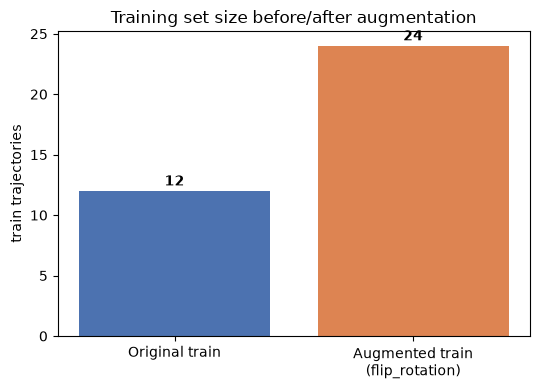

In [48]:
fig, ax = plt.subplots(figsize=(5.5, 4))
sizes = [len(train_ds), len(aug_ds)]
labels = ["Original train", "Augmented train\n(flip_rotation)"]
bars = ax.bar(labels, sizes, color=["#4C72B0", "#DD8452"])
for b, s in zip(bars, sizes):
    ax.annotate(str(s), (b.get_x() + b.get_width() / 2, s), textcoords="offset points",
               xytext=(0, 4), ha="center", fontweight="bold")
ax.set_ylabel("train trajectories")
ax.set_title("Training set size before/after augmentation")
plt.tight_layout()
plt.show()

## The model

In [49]:
MODEL_CLASS = AblationModelCustomRGB
MODEL_KWARGS = dict(
    d_model=D_MODEL, dropout=DROPOUT, cls_dropout=DROPOUT,
    freeze_visual_backbone=True,
)


def make_model_kwargs_for_config(config_key):
    """Builds a fresh rgb_encoder_factory whose use_cbam matches THIS config's own
    ABLATION_CONFIGS[config_key]["use_cbam"] setting. Previously rgb_encoder_factory was
    a single lambda hardcoded to use_cbam=True shared across every config in the sweep --
    which meant any config specifying use_cbam=False (ablation_1_no_cbam, baseline_a_early,
    baseline_b_late) silently had CBAM present on the RGB stream anyway, contradicting its
    own config and its own name. The default argument below (use_cbam=...) binds the
    correct value at call time, not at some later loop iteration, avoiding the classic
    late-binding-closure bug on top of fixing the original hardcoding bug."""
    use_cbam_for_rgb = ABLATION_CONFIGS[config_key]["use_cbam"]
    kwargs = dict(MODEL_KWARGS)
    kwargs["rgb_encoder_factory"] = lambda use_cbam=use_cbam_for_rgb: VisualEncoderToggle(
        "convnext_tiny", True, use_cbam=use_cbam)
    return kwargs


set_seed(0)
probe_model = MODEL_CLASS(ABLATION_CONFIGS["full_model"], **make_model_kwargs_for_config("full_model")).to(cfg["device"])
sample_batch = next(iter(val_loader))
profile = estimate_backbone_flops(probe_model, sample_batch, cfg["device"])
del probe_model
print(f"Model profile: {profile}")


/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_1520/677846431.py:22: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


Model profile: {'params_m': 32.47, 'flops_g': 39.026, 'latency_ms': 34.6}


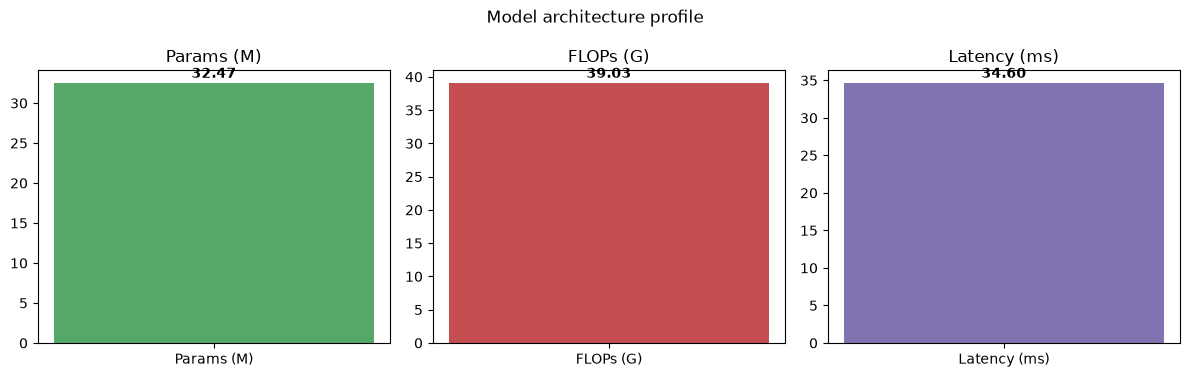

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
metrics = [("params_m", "Params (M)", "#55A868"), ("flops_g", "FLOPs (G)", "#C44E52"),
          ("latency_ms", "Latency (ms)", "#8172B2")]
for ax, (key, label, color) in zip(axes, metrics):
    val = profile.get(key)
    ax.bar([label], [val], color=color)
    ax.annotate(f"{val:.2f}" if val is not None else "n/a", (0, val or 0),
               textcoords="offset points", xytext=(0, 4), ha="center", fontweight="bold")
    ax.set_title(label)
plt.suptitle("Model architecture profile")
plt.tight_layout()
plt.show()

In [51]:
ABLATION_OUT = RUNS / "05_ablation_study"
ABLATION_OUT.mkdir(parents=True, exist_ok=True)
print(f"ABLATION_OUT redirected to: {ABLATION_OUT}")


ABLATION_OUT redirected to: /Users/sjanani2073/Desktop/convscript/runs/05_ablation_study


## 1. Training helper 

In [52]:
def train_one_run(run_name, seed, config_key, model_class, model_kwargs,
                  loader_train, loader_calib, loader_val, out_dir):
    set_seed(seed)
    run_dir = out_dir / f"{run_name}_seed{seed}" / f"seed_{seed}"
    run_dir.mkdir(parents=True, exist_ok=True)

    model = model_class(ABLATION_CONFIGS[config_key], **model_kwargs).to(cfg["device"])
    uncertainty_loss = UncertaintyWeightedLoss(n_tasks=3).to(cfg["device"])

    visual_backbone_ids = {id(p) for p in list(model.rgb_encoder.backbone.parameters()) +
                                          list(model.ir_encoder.backbone.parameters())}
    other_params = [p for p in model.parameters() if id(p) not in visual_backbone_ids]
    optimizer = AdamW([
        {"params": other_params, "lr": cfg["lr"]},
        {"params": list(model.rgb_encoder.backbone.parameters()) + list(model.ir_encoder.backbone.parameters()),
         "lr": cfg["lr_finetune"]},
        {"params": uncertainty_loss.parameters(), "lr": cfg["lr"]},
    ], weight_decay=cfg["weight_decay"])
    scheduler = CosineAnnealingLR(optimizer, T_max=cfg["epochs"])

    print(f"  --- {run_name} (config={config_key}) seed={seed} ---")
    best_f1, best_metrics, best_state, best_epoch = 0.0, None, None, None
    history = []
    for epoch in range(1, cfg["epochs"] + 1):
        if epoch == 6:
            model.unfreeze_visual_last_n(1)
        elif epoch == 8:
            model.unfreeze_visual_last_n(2)
        elif epoch == 12:
            model.unfreeze_visual_full()

        train_m = run_epoch(model, uncertainty_loss, loader_train, optimizer, cfg, train=True)
        thr = get_calibrated_threshold(model, uncertainty_loss, loader_calib, cfg)
        val_m = run_epoch(model, uncertainty_loss, loader_val, optimizer, cfg, train=False, threshold=thr)
        scheduler.step()
        history.append({"epoch": epoch, "train_f1": train_m["f1"], "train_loss": train_m.get("loss"),
                        "val_f1": val_m["f1"], "val_auc": val_m["auc"], "val_mae": val_m["mae"],
                        "threshold": thr})

        is_best = val_m["f1"] > best_f1
        if is_best:
            best_f1 = val_m["f1"]; best_metrics = val_m; best_epoch = epoch
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        star = " *" if is_best else ""
        print(f"    epoch {epoch:>2}/{cfg['epochs']}  train_loss={train_m.get('loss', float('nan')):.4f} "
             f"train_F1={train_m['f1']:.4f}  |  val_F1={val_m['f1']:.4f} val_AUC={val_m['auc']:.4f} "
             f"val_MAE={val_m['mae']:.4f} thr={thr:.2f}{star}")

    torch.save(best_state, run_dir / "model_state.pt")
    with open(run_dir / "history.json", "w") as f:
        json.dump(history, f, indent=2, default=str)
    print(f"  [{run_name} seed={seed}] BEST @ epoch {best_epoch}: val F1={best_metrics['f1']:.4f} "
         f"AUC={best_metrics['auc']:.4f} MAE={best_metrics['mae']:.4f} (thr={best_metrics['threshold']})\n")
    return best_metrics, history


## 2. Ensemble evaluation helper

In [ ]:
def collect_group_probs_valonly(prefix, seeds, config_key, out_dir, model_class, model_kwargs,
                                loader_calib, loader_val):
    calib_probs, val_probs, calib_labels, val_labels = [], [], None, None
    for seed in seeds:
        state_path = out_dir / f"{prefix}_seed{seed}" / f"seed_{seed}" / "model_state.pt"
        if not state_path.exists():
            print(f"  [skip] no checkpoint for {prefix} seed={seed}")
            continue
        model = model_class(ABLATION_CONFIGS[config_key], **model_kwargs).to(cfg["device"])
        model.load_state_dict(torch.load(state_path, map_location=cfg["device"]))
        uncertainty_loss = UncertaintyWeightedLoss(n_tasks=3).to(cfg["device"])
        c_p, c_l, _, _ = collect_probs_labels(model, uncertainty_loss, loader_calib, cfg)
        v_p, v_l, _, _ = collect_probs_labels(model, uncertainty_loss, loader_val, cfg)
        calib_probs.append(c_p); val_probs.append(v_p)
        calib_labels, val_labels = c_l, v_l
    return {"calib_probs": calib_probs, "val_probs": val_probs,
           "calib_labels": calib_labels, "val_labels": val_labels}


def ensemble_eval_valonly(group):
    n = len(group["calib_probs"])
    if n == 0:
        return {"n_seeds": 0, "val_f1": float("nan"), "val_auc": float("nan")}
    w = np.ones(n) / n
    avg_val = np.tensordot(w, np.stack(group["val_probs"]), axes=1) 
    per_seed_thresholds = []
    for seed_calib_probs in group["calib_probs"]:
        thr, _ = calibrate_threshold(seed_calib_probs[:, 1].tolist(), group["calib_labels"])
        per_seed_thresholds.append(thr)
    threshold = float(np.median(per_seed_thresholds))

    val_preds = (avg_val[:, 1] >= threshold).astype(int).tolist()
    val_f1 = f1_score(group["val_labels"], val_preds, average="binary", zero_division=0)
    val_macro_f1 = f1_score(group["val_labels"], val_preds, average="macro", zero_division=0)
    val_acc = accuracy_score(group["val_labels"], val_preds)
    try:
        val_auc = roc_auc_score(group["val_labels"], avg_val[:, 1])
    except ValueError:
        val_auc = float("nan")
    return {"n_seeds": n, "threshold": threshold, "per_seed_thresholds": per_seed_thresholds,
           "val_f1": round(float(val_f1), 4),
           "val_macro_f1": round(float(val_macro_f1), 4), "val_accuracy": round(float(val_acc), 4),
           "val_auc": round(float(val_auc), 4), "val_preds": val_preds,
           "val_probs_pos": avg_val[:, 1].tolist(), "val_labels": group["val_labels"]}


## 3. Profile all 7 configs (params / FLOPs / latency, architecture-only)

In [54]:
CONFIG_ORDER = ["baseline_a_early", "baseline_b_late", "ablation_1_no_cbam",
               "ablation_2_no_cross_attn", "ablation_3_lstm_not_transformer",
               "ablation_4_mean_impute_not_grud", "full_model"]
CONFIG_LABELS = {
    "baseline_a_early": "Baseline A\n(early fusion)",
    "baseline_b_late": "Baseline B\n(late fusion)",
    "ablation_1_no_cbam": "Ablation 1\n(no CBAM)",
    "ablation_2_no_cross_attn": "Ablation 2\n(no cross-attn)",
    "ablation_3_lstm_not_transformer": "Ablation 3\n(LSTM not Transformer)",
    "ablation_4_mean_impute_not_grud": "Ablation 4\n(mean-impute not GRU-D)",
    "full_model": "Full Model",
}

profiles = {}
for config_key in CONFIG_ORDER:
    set_seed(0)
    probe_model = MODEL_CLASS(ABLATION_CONFIGS[config_key], **make_model_kwargs_for_config(config_key)).to(cfg["device"])
    profiles[config_key] = estimate_backbone_flops(probe_model, sample_batch, cfg["device"])
    del probe_model
    print(f"  {config_key:<35} {profiles[config_key]}")


  baseline_a_early                    {'params_m': 32.06, 'flops_g': 39.02, 'latency_ms': 34.6}
  baseline_b_late                     {'params_m': 32.14, 'flops_g': 39.021, 'latency_ms': 38.2}


/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_1520/677846431.py:22: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


  ablation_1_no_cbam                  {'params_m': 32.19, 'flops_g': 39.021, 'latency_ms': 33.8}
  ablation_2_no_cross_attn            {'params_m': 32.47, 'flops_g': 39.026, 'latency_ms': 33.2}
  ablation_3_lstm_not_transformer     {'params_m': 32.34, 'flops_g': 39.025, 'latency_ms': 34.6}
  ablation_4_mean_impute_not_grud     {'params_m': 32.47, 'flops_g': 39.026, 'latency_ms': 35.5}
  full_model                          {'params_m': 32.47, 'flops_g': 39.026, 'latency_ms': 34.7}


## 4. Train

In [55]:
import traceback

ABLATION_SEEDS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

all_results = {} 

for config_key in CONFIG_ORDER:
    print("=" * 100)
    print(f"CONFIG: {config_key}  ({ABLATION_CONFIGS[config_key]})")
    print("=" * 100)
    seed_f1s, histories, failures = [], {}, []
    for seed in ABLATION_SEEDS:
        try:
            model_kwargs_this_config = make_model_kwargs_for_config(config_key)
            best_metrics, history = train_one_run(config_key, seed, config_key, MODEL_CLASS, model_kwargs_this_config,
                                                  train_loader, train_loader_calib, val_loader, ABLATION_OUT)
            seed_f1s.append(best_metrics["f1"])
            histories[seed] = history
        except Exception as e:
            print(f"  [FAILED] {config_key} seed={seed}: {type(e).__name__}: {e}")
            traceback.print_exc()
            failures.append(f"seed={seed}: {type(e).__name__}: {e}")

    all_results[config_key] = {"seed_f1s": seed_f1s, "histories": histories, "failures": failures}
    if seed_f1s:
        print(f">>> {config_key}: {len(seed_f1s)} seeds, mean val F1 = {np.mean(seed_f1s):.4f} "
             f"(std={np.std(seed_f1s):.4f})\n")


CONFIG: baseline_a_early  ({'fusion_type': 'early', 'use_cbam': False, 'use_cross_attn': False, 'temporal_type': 'lstm', 'missing_handling': 'mean'})
  --- baseline_a_early (config=baseline_a_early) seed=0 ---
    epoch  1/30  train_loss=2.2706 train_F1=0.6667  |  val_F1=0.6667 val_AUC=0.6111 val_MAE=2.1641 thr=0.50 *
    epoch  2/30  train_loss=2.7807 train_F1=0.5000  |  val_F1=0.6667 val_AUC=0.4444 val_MAE=2.1612 thr=0.10
    epoch  3/30  train_loss=2.4941 train_F1=0.4545  |  val_F1=0.6667 val_AUC=0.5278 val_MAE=2.1637 thr=0.10
    epoch  4/30  train_loss=1.3413 train_F1=0.7647  |  val_F1=0.6667 val_AUC=0.4722 val_MAE=2.1599 thr=0.10
    epoch  5/30  train_loss=2.3346 train_F1=0.6061  |  val_F1=0.6667 val_AUC=0.5000 val_MAE=2.1625 thr=0.10
    epoch  6/30  train_loss=1.3679 train_F1=0.6286  |  val_F1=0.6667 val_AUC=0.6389 val_MAE=2.1574 thr=0.10
    epoch  7/30  train_loss=1.7914 train_F1=0.6286  |  val_F1=0.6667 val_AUC=0.4167 val_MAE=2.1579 thr=0.10
    epoch  8/30  train_loss=1.52

/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_1520/677846431.py:22: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


  --- ablation_1_no_cbam (config=ablation_1_no_cbam) seed=0 ---
    epoch  1/30  train_loss=3.3189 train_F1=0.4615  |  val_F1=0.7059 val_AUC=0.3333 val_MAE=2.1840 thr=0.52 *
    epoch  2/30  train_loss=1.7484 train_F1=0.7143  |  val_F1=0.6667 val_AUC=0.6111 val_MAE=2.1803 thr=0.10
    epoch  3/30  train_loss=1.7630 train_F1=0.6667  |  val_F1=0.6667 val_AUC=0.5000 val_MAE=2.1989 thr=0.10
    epoch  4/30  train_loss=2.6236 train_F1=0.6154  |  val_F1=0.7059 val_AUC=0.5556 val_MAE=2.1669 thr=0.61
    epoch  5/30  train_loss=2.1258 train_F1=0.5625  |  val_F1=0.6250 val_AUC=0.3611 val_MAE=2.1721 thr=0.63
    epoch  6/30  train_loss=1.7986 train_F1=0.6429  |  val_F1=0.7500 val_AUC=0.6111 val_MAE=2.1843 thr=0.66 *
    epoch  7/30  train_loss=1.8993 train_F1=0.5806  |  val_F1=0.8000 val_AUC=0.5000 val_MAE=2.1687 thr=0.68 *
    epoch  8/30  train_loss=2.6086 train_F1=0.5185  |  val_F1=0.5714 val_AUC=0.5000 val_MAE=2.1631 thr=0.67
    epoch  9/30  train_loss=2.1914 train_F1=0.5926  |  val_F1=0.66

/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_1520/677846431.py:22: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


  --- ablation_1_no_cbam (config=ablation_1_no_cbam) seed=1 ---
    epoch  1/30  train_loss=1.3992 train_F1=0.6207  |  val_F1=0.7500 val_AUC=0.9444 val_MAE=2.1982 thr=0.55 *
    epoch  2/30  train_loss=2.3464 train_F1=0.5385  |  val_F1=0.8571 val_AUC=0.8056 val_MAE=2.1922 thr=0.63 *
    epoch  3/30  train_loss=2.4146 train_F1=0.5000  |  val_F1=0.6667 val_AUC=0.6111 val_MAE=2.1627 thr=0.10
    epoch  4/30  train_loss=1.4363 train_F1=0.5517  |  val_F1=0.6667 val_AUC=0.8611 val_MAE=2.2184 thr=0.55
    epoch  5/30  train_loss=2.9430 train_F1=0.6667  |  val_F1=0.8000 val_AUC=0.8889 val_MAE=2.1920 thr=0.63
    epoch  6/30  train_loss=1.7757 train_F1=0.5455  |  val_F1=0.8333 val_AUC=0.8889 val_MAE=2.1727 thr=0.65
    epoch  7/30  train_loss=1.2964 train_F1=0.7857  |  val_F1=0.6667 val_AUC=0.7222 val_MAE=2.1439 thr=0.66
    epoch  8/30  train_loss=1.7207 train_F1=0.7568  |  val_F1=0.7273 val_AUC=0.9444 val_MAE=2.1860 thr=0.68
    epoch  9/30  train_loss=3.0272 train_F1=0.8235  |  val_F1=0.5882

...

  --- full_model (config=full_model) seed=7 ---
    epoch  1/30  train_loss=2.8959 train_F1=0.2222  |  val_F1=0.5882 val_AUC=0.4444 val_MAE=2.1812 thr=0.35 *
    epoch  2/30  train_loss=1.8530 train_F1=0.3158  |  val_F1=0.6250 val_AUC=0.5833 val_MAE=2.2156 thr=0.35 *
    epoch  3/30  train_loss=2.2461 train_F1=0.2857  |  val_F1=0.6667 val_AUC=0.4444 val_MAE=2.2251 thr=0.10 *
    epoch  4/30  train_loss=1.9750 train_F1=0.5833  |  val_F1=0.6667 val_AUC=0.4722 val_MAE=2.1755 thr=0.10
    epoch  5/30  train_loss=2.4288 train_F1=0.2353  |  val_F1=0.6667 val_AUC=0.6389 val_MAE=2.1627 thr=0.49
    epoch  6/30  train_loss=2.0831 train_F1=0.5000  |  val_F1=0.6667 val_AUC=0.5833 val_MAE=2.2050 thr=0.52
    epoch  7/30  train_loss=2.4206 train_F1=0.4800  |  val_F1=0.6667 val_AUC=0.5000 val_MAE=2.1900 thr=0.54
    epoch  8/30  train_loss=2.1190 train_F1=0.6316  |  val_F1=0.7143 val_AUC=0.5000 val_MAE=2.1585 thr=0.58 *
    epoch  9/30  train_loss=1.8581 train_F1=0.5926  |  val_F1=0.4000 val_AUC=0.5

/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_1520/677846431.py:22: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


  --- full_model (config=full_model) seed=8 ---
    epoch  1/30  train_loss=2.4104 train_F1=0.0000  |  val_F1=0.7059 val_AUC=0.4722 val_MAE=2.1436 thr=0.46 *
    epoch  2/30  train_loss=2.7524 train_F1=0.3333  |  val_F1=0.6667 val_AUC=0.7778 val_MAE=2.1994 thr=0.10
    epoch  3/30  train_loss=2.6718 train_F1=0.3333  |  val_F1=0.6667 val_AUC=0.1389 val_MAE=2.2119 thr=0.10
    epoch  4/30  train_loss=2.3121 train_F1=0.3333  |  val_F1=0.6667 val_AUC=0.2778 val_MAE=2.1424 thr=0.10
    epoch  5/30  train_loss=2.1412 train_F1=0.1111  |  val_F1=0.6667 val_AUC=0.5556 val_MAE=2.2026 thr=0.10
    epoch  6/30  train_loss=2.0103 train_F1=0.4615  |  val_F1=0.6250 val_AUC=0.4722 val_MAE=2.2232 thr=0.52
    epoch  7/30  train_loss=1.8504 train_F1=0.5600  |  val_F1=0.6667 val_AUC=0.4167 val_MAE=2.1626 thr=0.56
    epoch  8/30  train_loss=2.2092 train_F1=0.4545  |  val_F1=0.6667 val_AUC=0.5833 val_MAE=2.1617 thr=0.57
    epoch  9/30  train_loss=2.1518 train_F1=0.5926  |  val_F1=0.6667 val_AUC=0.4167 va

/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_1520/677846431.py:22: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


  --- full_model (config=full_model) seed=9 ---
    epoch  1/30  train_loss=2.3337 train_F1=0.5000  |  val_F1=0.6667 val_AUC=0.5556 val_MAE=2.1681 thr=0.10 *
    epoch  2/30  train_loss=2.0277 train_F1=0.4000  |  val_F1=0.6667 val_AUC=0.5556 val_MAE=2.1390 thr=0.10
    epoch  3/30  train_loss=2.6266 train_F1=0.4000  |  val_F1=0.6667 val_AUC=0.6389 val_MAE=2.1725 thr=0.56
    epoch  4/30  train_loss=2.5521 train_F1=0.6207  |  val_F1=0.7059 val_AUC=0.8333 val_MAE=2.1179 thr=0.53 *
    epoch  5/30  train_loss=3.3000 train_F1=0.5600  |  val_F1=0.6667 val_AUC=0.6944 val_MAE=2.1365 thr=0.56
    epoch  6/30  train_loss=1.9751 train_F1=0.5714  |  val_F1=0.5882 val_AUC=0.5278 val_MAE=2.1019 thr=0.55
    epoch  7/30  train_loss=1.8422 train_F1=0.5714  |  val_F1=0.6667 val_AUC=0.6389 val_MAE=2.1502 thr=0.51
    epoch  8/30  train_loss=2.2531 train_F1=0.6923  |  val_F1=0.7500 val_AUC=0.7500 val_MAE=2.1330 thr=0.56 *
    epoch  9/30  train_loss=2.6248 train_F1=0.3846  |  val_F1=0.7059 val_AUC=0.583

## 5. Per-config training curves 

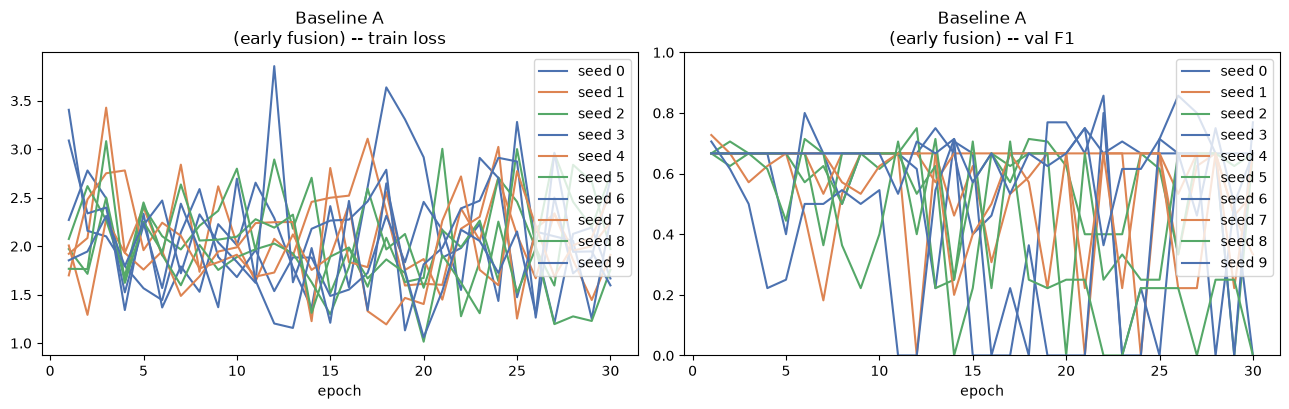

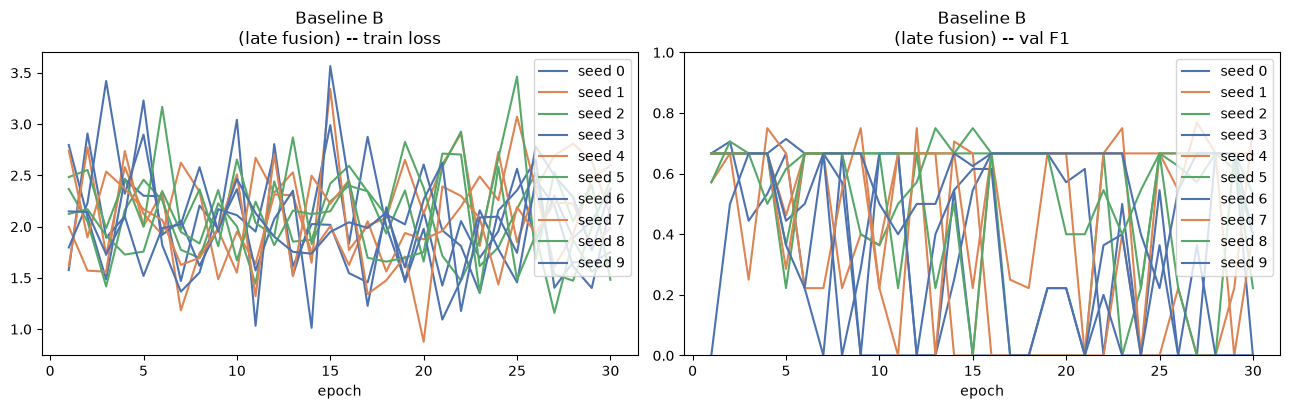

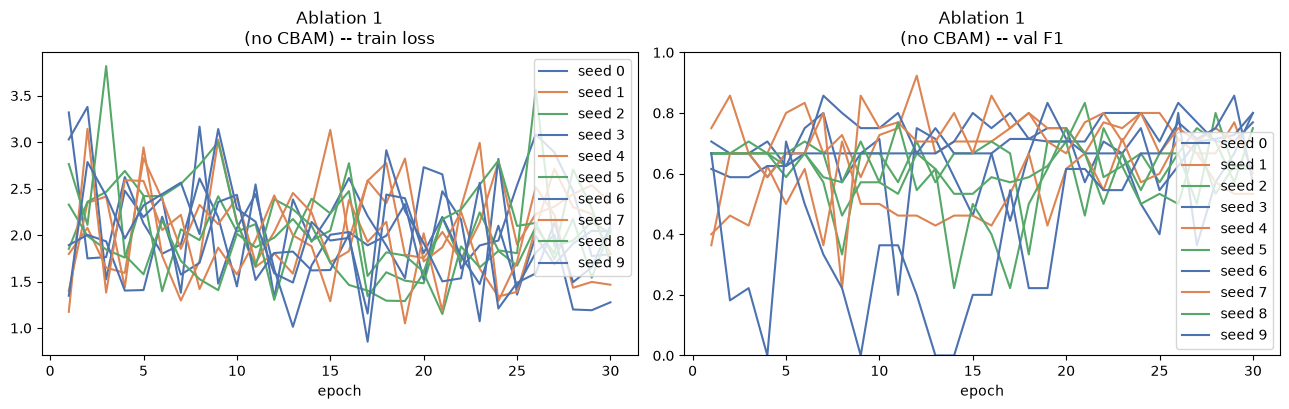

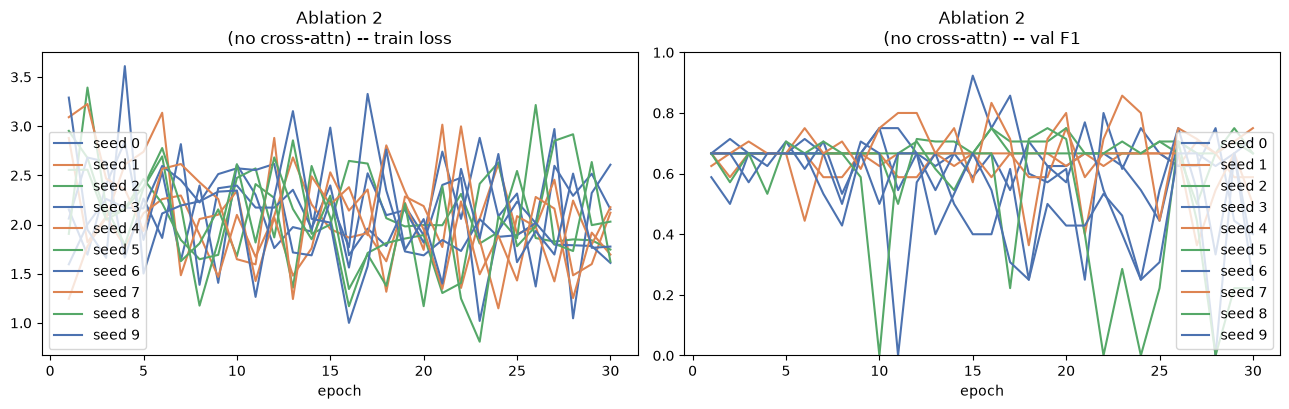

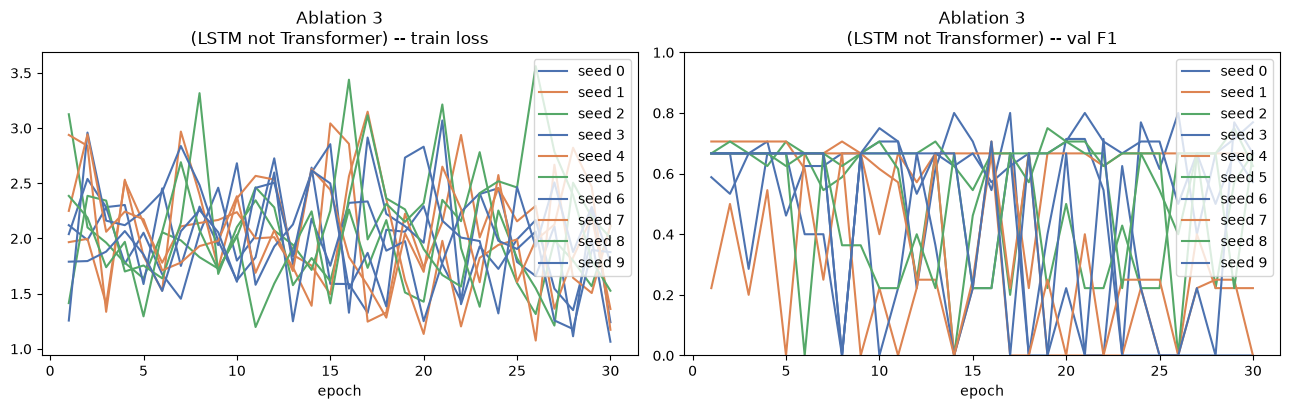

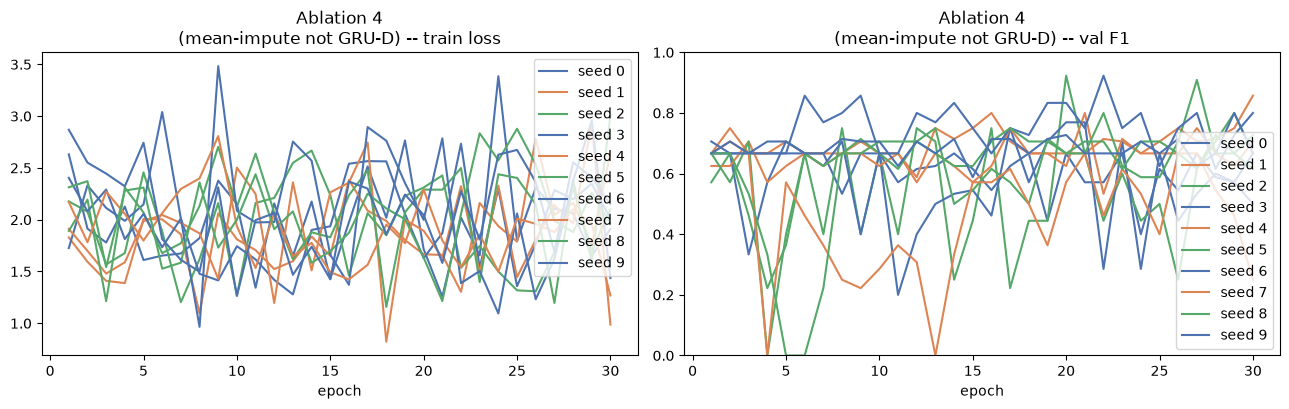

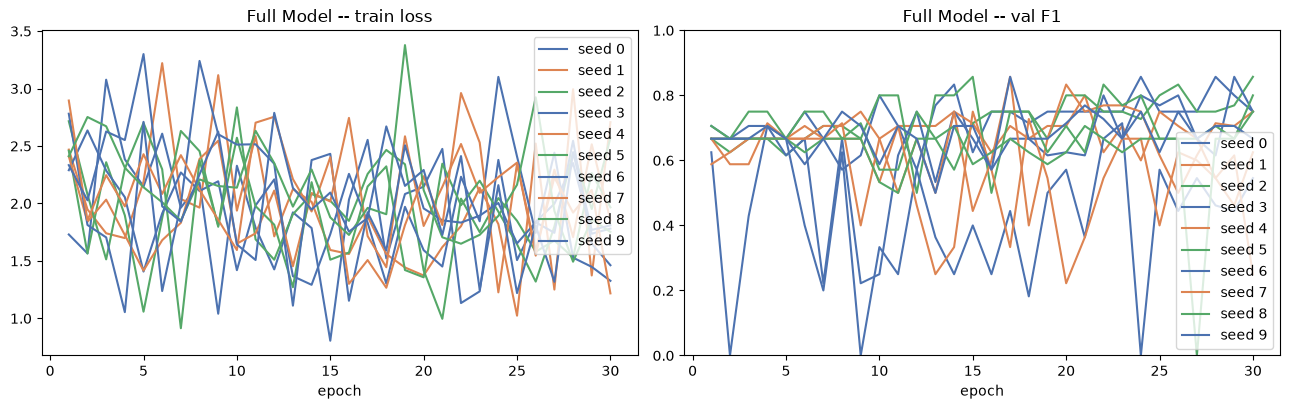

In [56]:
SEED_COLORS = ["#4C72B0", "#DD8452", "#55A868"]

for config_key in CONFIG_ORDER:
    histories = all_results[config_key]["histories"]
    if not histories:
        continue
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
    for i, (seed, hist) in enumerate(histories.items()):
        epochs = [h["epoch"] for h in hist]
        color = SEED_COLORS[i % len(SEED_COLORS)]
        axes[0].plot(epochs, [h["train_loss"] for h in hist], color=color, label=f"seed {seed}")
        axes[1].plot(epochs, [h["val_f1"] for h in hist], color=color, label=f"seed {seed}")
    axes[0].set_title(f"{CONFIG_LABELS[config_key]} -- train loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
    axes[1].set_title(f"{CONFIG_LABELS[config_key]} -- val F1"); axes[1].set_xlabel("epoch"); axes[1].legend()
    axes[1].set_ylim(0, 1)
    plt.tight_layout(); plt.show()


## 6. Ensemble evaluation 

In [57]:
ensemble_results = {}
for config_key in CONFIG_ORDER:
    model_kwargs_this_config = make_model_kwargs_for_config(config_key)
    group = collect_group_probs_valonly(config_key, ABLATION_SEEDS, config_key, ABLATION_OUT,
                                        MODEL_CLASS, model_kwargs_this_config, train_loader_calib, val_loader)
    ensemble_results[config_key] = ensemble_eval_valonly(group)
    r = ensemble_results[config_key]
    print(f"  {config_key:<35} ensemble val F1={r['val_f1']:.4f}  AUC={r['val_auc']:.4f}  "
         f"macroF1={r.get('val_macro_f1', float('nan')):.4f}  acc={r.get('val_accuracy', float('nan')):.4f}")


  baseline_a_early                    ensemble val F1=0.7059  AUC=0.6111  macroF1=0.4958  acc=0.5833
  baseline_b_late                     ensemble val F1=0.6667  AUC=0.6667  macroF1=0.3333  acc=0.5000


/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_1520/677846431.py:22: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


  ablation_1_no_cbam                  ensemble val F1=0.7500  AUC=0.8056  macroF1=0.6250  acc=0.6667


/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_1520/677846431.py:22: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


  ablation_2_no_cross_attn            ensemble val F1=0.6667  AUC=0.9722  macroF1=0.3333  acc=0.5000
  ablation_3_lstm_not_transformer     ensemble val F1=0.8571  AUC=0.6667  macroF1=0.8286  acc=0.8333


/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_1520/677846431.py:22: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


  ablation_4_mean_impute_not_grud     ensemble val F1=0.9091  AUC=0.9722  macroF1=0.9161  acc=0.9167


/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_1520/677846431.py:22: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


  full_model                          ensemble val F1=0.8000  AUC=0.9444  macroF1=0.7333  acc=0.7500


## 7. Ranked comparison 

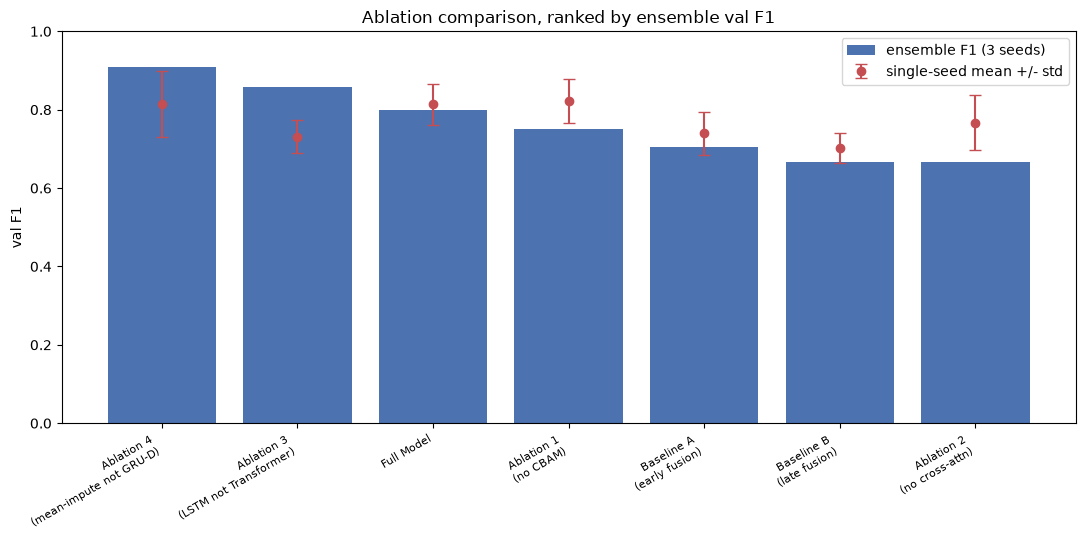

Ranked (by ensemble val F1):
  Ablation 4 (mean-impute not GRU-D)       ensemble=0.9091  single-seed mean=0.8154+/-0.0841
  Ablation 3 (LSTM not Transformer)        ensemble=0.8571  single-seed mean=0.7315+/-0.0432
  Full Model                               ensemble=0.8000  single-seed mean=0.8133+/-0.0529
  Ablation 1 (no CBAM)                     ensemble=0.7500  single-seed mean=0.8225+/-0.0565
  Baseline A (early fusion)                ensemble=0.7059  single-seed mean=0.7396+/-0.0546
  Baseline B (late fusion)                 ensemble=0.6667  single-seed mean=0.7023+/-0.0394
  Ablation 2 (no cross-attn)               ensemble=0.6667  single-seed mean=0.7672+/-0.0691


In [58]:
ranked_keys = sorted(CONFIG_ORDER, key=lambda k: -ensemble_results[k]["val_f1"])

fig, ax = plt.subplots(figsize=(11, 5.5))
means = [np.mean(all_results[k]["seed_f1s"]) if all_results[k]["seed_f1s"] else 0 for k in ranked_keys]
stds  = [np.std(all_results[k]["seed_f1s"]) if all_results[k]["seed_f1s"] else 0 for k in ranked_keys]
ensembles = [ensemble_results[k]["val_f1"] for k in ranked_keys]
labels = [CONFIG_LABELS[k] for k in ranked_keys]
x = np.arange(len(ranked_keys))

ax.bar(x, ensembles, color="#4C72B0", label="ensemble F1 (3 seeds)")
ax.errorbar(x, means, yerr=stds, fmt="o", color="#C44E52", capsize=4, label="single-seed mean +/- std")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("val F1"); ax.set_ylim(0, 1)
ax.set_title("Ablation comparison, ranked by ensemble val F1")
ax.legend()
plt.tight_layout(); plt.show()

print("Ranked (by ensemble val F1):")
for k in ranked_keys:
    print(f"  {CONFIG_LABELS[k].replace(chr(10), ' '):<40} ensemble={ensemble_results[k]['val_f1']:.4f}  "
         f"single-seed mean={np.mean(all_results[k]['seed_f1s']):.4f}+/-{np.std(all_results[k]['seed_f1s']):.4f}")


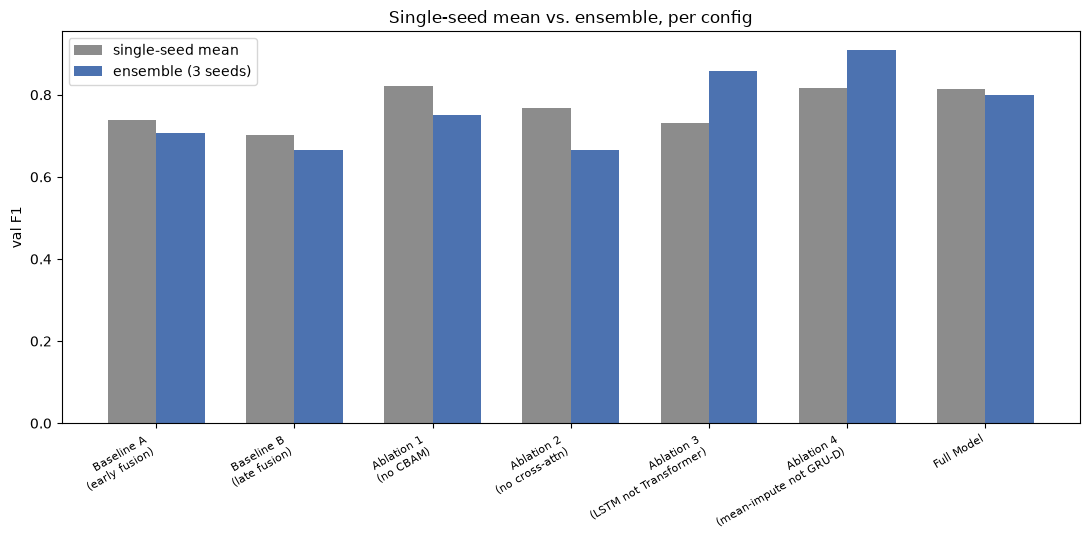

Ensembling delta (ensemble - single-seed mean):
  baseline_a_early                    -0.0337
  baseline_b_late                     -0.0356
  ablation_1_no_cbam                  -0.0725
  ablation_2_no_cross_attn            -0.1005
  ablation_3_lstm_not_transformer     +0.1256
  ablation_4_mean_impute_not_grud     +0.0937
  full_model                          -0.0133


In [59]:
fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(CONFIG_ORDER))
width = 0.35
single_means = [np.mean(all_results[k]["seed_f1s"]) for k in CONFIG_ORDER]
ensemble_vals = [ensemble_results[k]["val_f1"] for k in CONFIG_ORDER]
ax.bar(x - width/2, single_means, width, label="single-seed mean", color="#8C8C8C")
ax.bar(x + width/2, ensemble_vals, width, label="ensemble (3 seeds)", color="#4C72B0")
ax.set_xticks(x); ax.set_xticklabels([CONFIG_LABELS[k] for k in CONFIG_ORDER], rotation=30, ha="right", fontsize=8)
ax.set_ylabel("val F1"); ax.set_title("Single-seed mean vs. ensemble, per config")
ax.legend()
plt.tight_layout(); plt.show()

print("Ensembling delta (ensemble - single-seed mean):")
for k in CONFIG_ORDER:
    delta = ensemble_results[k]["val_f1"] - np.mean(all_results[k]["seed_f1s"])
    print(f"  {k:<35} {delta:+.4f}")


## 8. Per-seed F1 spread across configs 

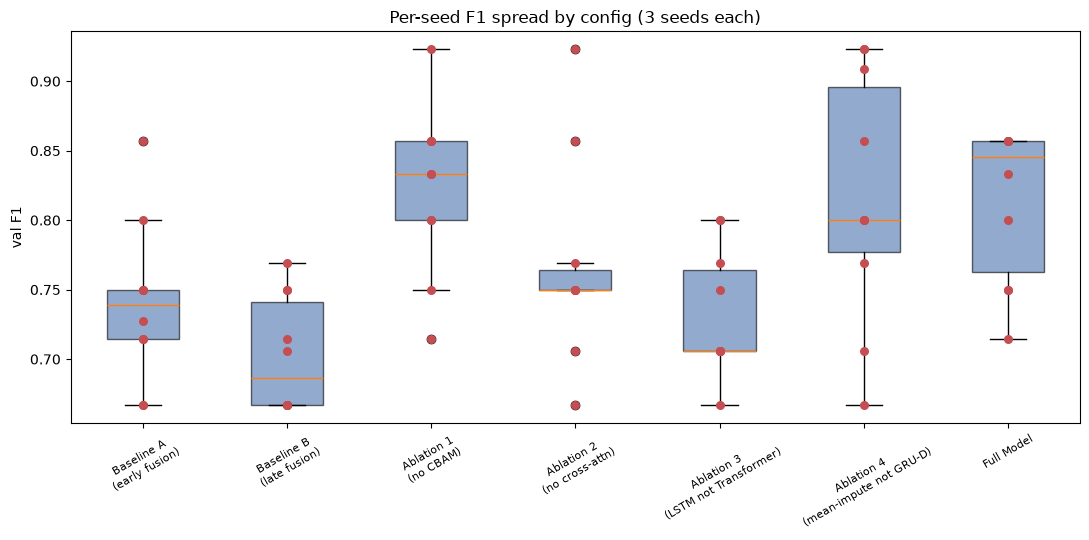

In [60]:
fig, ax = plt.subplots(figsize=(11, 5.5))
data = [all_results[k]["seed_f1s"] for k in CONFIG_ORDER]
bp = ax.boxplot(data, tick_labels=[CONFIG_LABELS[k] for k in CONFIG_ORDER], patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#4C72B0"); patch.set_alpha(0.6)
for i, k in enumerate(CONFIG_ORDER):
    ys = all_results[k]["seed_f1s"]
    ax.scatter([i + 1] * len(ys), ys, color="#C44E52", zorder=3, s=30)
ax.set_ylabel("val F1"); ax.set_title("Per-seed F1 spread by config (3 seeds each)")
ax.tick_params(axis="x", rotation=30)
plt.setp(ax.get_xticklabels(), fontsize=8)
plt.tight_layout(); plt.show()


## 9. Component contribution 

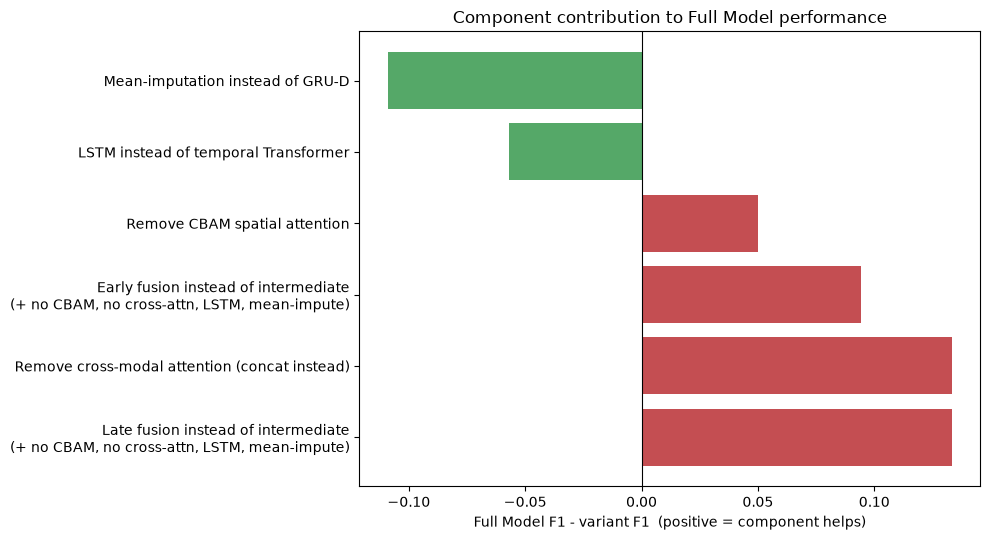

  Late fusion instead of intermediate                delta=+0.1333  (helps)
  Remove cross-modal attention (concat instead)      delta=+0.1333  (helps)
  Early fusion instead of intermediate               delta=+0.0941  (helps)
  Remove CBAM spatial attention                      delta=+0.0500  (helps)
  LSTM instead of temporal Transformer               delta=-0.0571  (hurts (or noise))
  Mean-imputation instead of GRU-D                   delta=-0.1091  (hurts (or noise))


In [61]:
full_f1 = ensemble_results["full_model"]["val_f1"]
component_labels = {
    "baseline_a_early": "Early fusion instead of intermediate\n(+ no CBAM, no cross-attn, LSTM, mean-impute)",
    "baseline_b_late": "Late fusion instead of intermediate\n(+ no CBAM, no cross-attn, LSTM, mean-impute)",
    "ablation_1_no_cbam": "Remove CBAM spatial attention",
    "ablation_2_no_cross_attn": "Remove cross-modal attention (concat instead)",
    "ablation_3_lstm_not_transformer": "LSTM instead of temporal Transformer",
    "ablation_4_mean_impute_not_grud": "Mean-imputation instead of GRU-D",
}
deltas = {k: full_f1 - ensemble_results[k]["val_f1"] for k in component_labels}
ranked_deltas = sorted(deltas.items(), key=lambda kv: -kv[1])

fig, ax = plt.subplots(figsize=(10, 5.5))
colors = ["#C44E52" if d > 0 else "#55A868" for _, d in ranked_deltas]
ax.barh([component_labels[k] for k, _ in ranked_deltas], [d for _, d in ranked_deltas], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Full Model F1 - variant F1  (positive = component helps)")
ax.set_title("Component contribution to Full Model performance")
plt.tight_layout(); plt.show()

for k, d in ranked_deltas:
    verdict = "helps" if d > 0.01 else ("hurts (or noise)" if d < -0.01 else "~no effect at this seed count")
    print(f"  {component_labels[k].splitlines()[0]:<50} delta={d:+.4f}  ({verdict})")


## 10. Multi-metric radar chart 

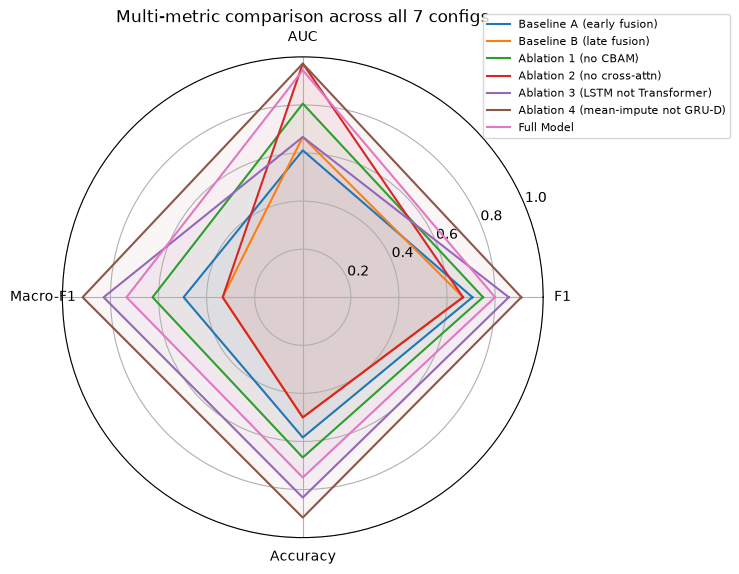

In [62]:
radar_metrics = ["val_f1", "val_auc", "val_macro_f1", "val_accuracy"]
radar_metric_labels = ["F1", "AUC", "Macro-F1", "Accuracy"]
angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": "polar"})
cmap = plt.get_cmap("tab10")
for i, config_key in enumerate(CONFIG_ORDER):
    r = ensemble_results[config_key]
    values = [r.get(m, 0) or 0 for m in radar_metrics]
    values += values[:1]
    ax.plot(angles, values, label=CONFIG_LABELS[config_key].replace("\n", " "), color=cmap(i), linewidth=1.5)
    ax.fill(angles, values, color=cmap(i), alpha=0.05)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(radar_metric_labels)
ax.set_ylim(0, 1)
ax.set_title("Multi-metric comparison across all 7 configs")
ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.1), fontsize=8)
plt.tight_layout(); plt.show()


## 11. Confusion matrices

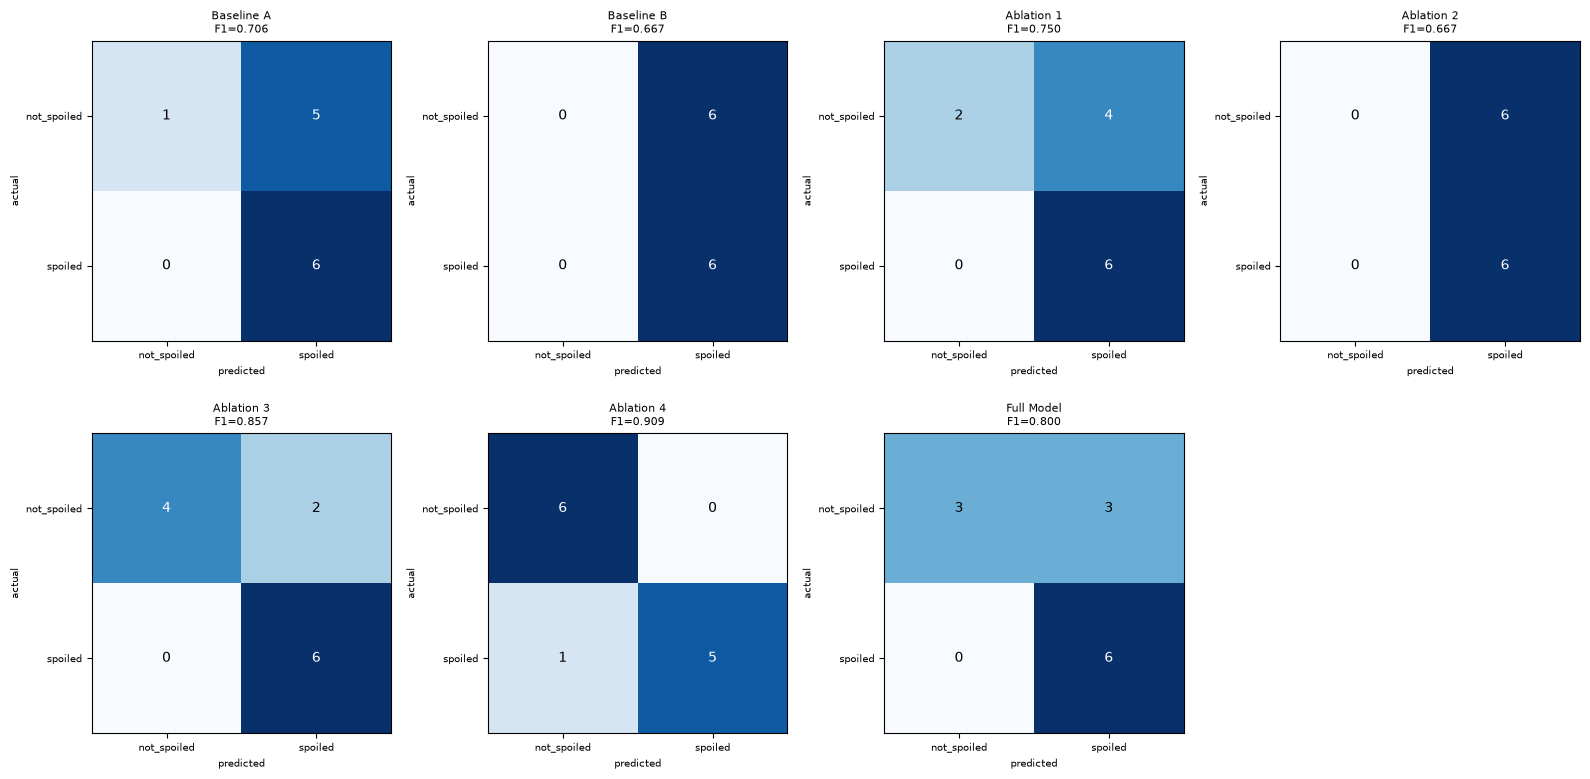

In [63]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, config_key in enumerate(CONFIG_ORDER):
    r = ensemble_results[config_key]
    cm = confusion_matrix(r["val_labels"], r["val_preds"], labels=[0, 1])
    im = axes[i].imshow(cm, cmap="Blues")
    axes[i].set_xticks([0, 1]); axes[i].set_xticklabels(["not_spoiled", "spoiled"], fontsize=7)
    axes[i].set_yticks([0, 1]); axes[i].set_yticklabels(["not_spoiled", "spoiled"], fontsize=7)
    axes[i].set_xlabel("predicted", fontsize=7); axes[i].set_ylabel("actual", fontsize=7)
    for r_i in range(2):
        for c_i in range(2):
            axes[i].text(c_i, r_i, cm[r_i, c_i], ha="center", va="center",
                        color="white" if cm[r_i, c_i] > cm.max() / 2 else "black", fontsize=10)
    axes[i].set_title(f"{CONFIG_LABELS[config_key].splitlines()[0]}\nF1={r['val_f1']:.3f}", fontsize=8)
for j in range(len(CONFIG_ORDER), len(axes)):
    axes[j].axis("off")
plt.tight_layout(); plt.show()


## 12. ROC curves 

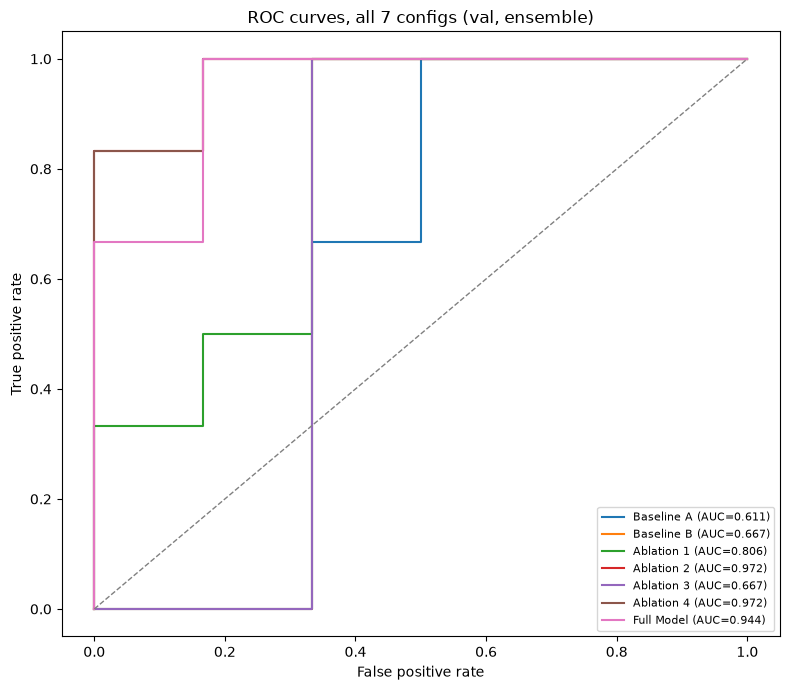

In [64]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 7))
cmap = plt.get_cmap("tab10")
for i, config_key in enumerate(CONFIG_ORDER):
    r = ensemble_results[config_key]
    fpr, tpr, _ = roc_curve(r["val_labels"], r["val_probs_pos"])
    ax.plot(fpr, tpr, color=cmap(i), label=f"{CONFIG_LABELS[config_key].splitlines()[0]} (AUC={r['val_auc']:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC curves, all 7 configs (val, ensemble)")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()


## 13. Params / FLOPs / latency 

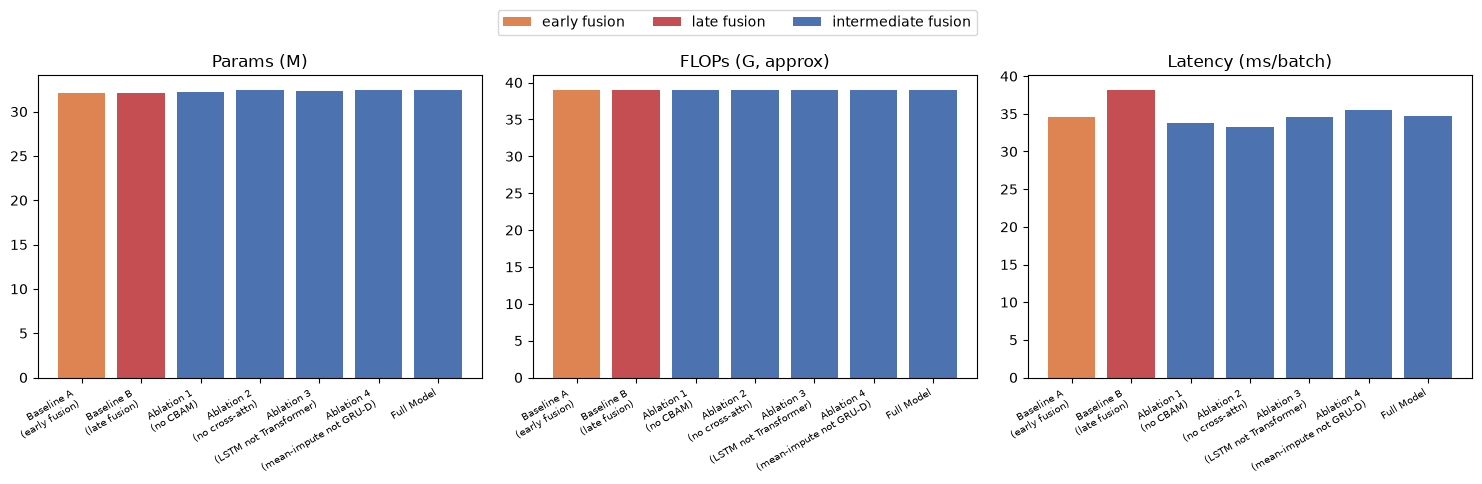

In [65]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metric_keys = ["params_m", "flops_g", "latency_ms"]
metric_titles = ["Params (M)", "FLOPs (G, approx)", "Latency (ms/batch)"]
colors_fusion = {"early": "#DD8452", "late": "#C44E52", "intermediate": "#4C72B0"}
for ax, mk, title in zip(axes, metric_keys, metric_titles):
    vals = [profiles[k].get(mk) or 0 for k in CONFIG_ORDER]
    bar_colors = [colors_fusion[ABLATION_CONFIGS[k]["fusion_type"]] for k in CONFIG_ORDER]
    ax.bar(range(len(CONFIG_ORDER)), vals, color=bar_colors)
    ax.set_xticks(range(len(CONFIG_ORDER)))
    ax.set_xticklabels([CONFIG_LABELS[k] for k in CONFIG_ORDER], rotation=30, ha="right", fontsize=7)
    ax.set_title(title)
legend_handles = [Patch(facecolor=c, label=f"{f} fusion") for f, c in colors_fusion.items()]
fig.legend(handles=legend_handles, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.08))
plt.tight_layout(); plt.show()


## 14. Final summary table

In [66]:
import pandas as pd

rows = []
for config_key in CONFIG_ORDER:
    cfg_spec = ABLATION_CONFIGS[config_key]
    r = ensemble_results[config_key]
    f1s = all_results[config_key]["seed_f1s"]
    prof = profiles[config_key]
    rows.append({
        "Config": config_key,
        "Fusion": cfg_spec["fusion_type"],
        "CBAM": cfg_spec["use_cbam"],
        "Cross-attn": cfg_spec["use_cross_attn"],
        "Temporal": cfg_spec["temporal_type"],
        "Missing-handling": cfg_spec["missing_handling"],
        "Single-seed F1 (mean+/-std)": f"{np.mean(f1s):.4f}+/-{np.std(f1s):.4f}" if f1s else "n/a",
        "Ensemble F1": r["val_f1"],
        "Ensemble AUC": r["val_auc"],
        "Params(M)": prof["params_m"],
        "FLOPs(G)": prof["flops_g"],
        "Latency(ms)": prof["latency_ms"],
    })

summary_df = pd.DataFrame(rows).sort_values("Ensemble F1", ascending=False)
print(summary_df.to_string(index=False))


                         Config       Fusion  CBAM  Cross-attn    Temporal Missing-handling Single-seed F1 (mean+/-std)  Ensemble F1  Ensemble AUC  Params(M)  FLOPs(G)  Latency(ms)
ablation_4_mean_impute_not_grud intermediate  True        True transformer             mean             0.8154+/-0.0841       0.9091        0.9722      32.47    39.026         35.5
ablation_3_lstm_not_transformer intermediate  True        True        lstm             grud             0.7315+/-0.0432       0.8571        0.6667      32.34    39.025         34.6
                     full_model intermediate  True        True transformer             grud             0.8133+/-0.0529       0.8000        0.9444      32.47    39.026         34.7
             ablation_1_no_cbam intermediate False        True transformer             grud             0.8225+/-0.0565       0.7500        0.8056      32.19    39.021         33.8
               baseline_a_early        early False       False        lstm             mean    

### Test

In [67]:
FUSION_OUT = RUNS / "04_fusion_model"
NOCBAM_OUT = RUNS / "no_cbam_candidate"
RUN_KEY = "model_a_winner"
TEST_BOOTSTRAP_RESULT_PATH = RUNS / "test_bootstrap_comparison.json"

if TEST_BOOTSTRAP_RESULT_PATH.exists():
    with open(TEST_BOOTSTRAP_RESULT_PATH) as f:
        print("[GUARD] Test bootstrap comparison already run")
        print(json.dumps(json.load(f), indent=2))
else:
    test_ds = DayLevelSequenceDataset(split="test", shared_pixel_cache=train_ds._pixel_cache)
    test_loader = DataLoader(test_ds, batch_size=1, shuffle=False,
                              collate_fn=day_sequence_collate, num_workers=0)

    def collect_ensemble_test_probs(config_key, ckpt_dir_fn, n_seeds=10):
        seed_probs, labels_ref = [], None
        for seed in range(n_seeds):
            ckpt_path = ckpt_dir_fn(seed)
            if not ckpt_path.exists():
                print(f"  [SKIP] {config_key} seed {seed}: checkpoint not found at {ckpt_path}")
                continue
            model = AblationModelCustomRGB(ABLATION_CONFIGS[config_key],
                                            **make_model_kwargs_for_config(config_key)).to(cfg["device"])
            model.load_state_dict(torch.load(ckpt_path, map_location=cfg["device"]))
            uncertainty_loss = UncertaintyWeightedLoss(n_tasks=3).to(cfg["device"])
            probs, labels, _, _ = collect_probs_labels(model, uncertainty_loss, test_loader, cfg)
            if labels_ref is None:
                labels_ref = labels
            else:
                assert labels == labels_ref, f"test label order mismatch for {config_key} seed {seed}"
            seed_probs.append(probs[:, 1])
            del model
        return np.mean(seed_probs, axis=0), labels_ref, len(seed_probs)

    print("Recomputing Full Model's test predictions")
    full_probs, full_labels, n_full = collect_ensemble_test_probs(
        "full_model", lambda s: FUSION_OUT / RUN_KEY / f"seed_{s}" / "model_state.pt")
    print(f"  {n_full} seeds collected.")

    print("Recomputing No-CBAM candidate's test predictions")
    nocbam_probs, nocbam_labels, n_nocbam = collect_ensemble_test_probs(
        "ablation_1_no_cbam", lambda s: NOCBAM_OUT / f"seed_{s}" / "model_state.pt")
    print(f"  {n_nocbam} seeds collected.")

    assert full_labels == nocbam_labels, "label order mismatch"
    TEST_LABELS_ARR = np.array(full_labels)
    N_TEST = len(TEST_LABELS_ARR)

    FULL_THRESHOLD = 0.660    
    with open(NOCBAM_OUT / "no_cbam_test_evaluation.json") as f:
        NOCBAM_THRESHOLD = json.load(f)["threshold"]

    full_preds = (full_probs >= FULL_THRESHOLD).astype(int)
    nocbam_preds = (nocbam_probs >= NOCBAM_THRESHOLD).astype(int)
    observed_full_f1 = f1_score(TEST_LABELS_ARR, full_preds, average="binary", zero_division=0)
    observed_nocbam_f1 = f1_score(TEST_LABELS_ARR, nocbam_preds, average="binary", zero_division=0)
    observed_full_auc = roc_auc_score(TEST_LABELS_ARR, full_probs)
    observed_nocbam_auc = roc_auc_score(TEST_LABELS_ARR, nocbam_probs)
    print(f"\nRecomputed check -- Full Model: F1={observed_full_f1:.4f} AUC={observed_full_auc:.4f} "
          f"(compare to reported 0.8000 / 0.7333)")
    print(f"Recomputed check -- No-CBAM:   F1={observed_nocbam_f1:.4f} AUC={observed_nocbam_auc:.4f}")

    N_BOOTSTRAP = 10000
    rng = np.random.default_rng(0)
    boot_full_f1 = np.zeros(N_BOOTSTRAP); boot_nocbam_f1 = np.zeros(N_BOOTSTRAP)
    boot_full_auc = np.full(N_BOOTSTRAP, np.nan); boot_nocbam_auc = np.full(N_BOOTSTRAP, np.nan)

    for b in range(N_BOOTSTRAP):
        idx = rng.integers(0, N_TEST, size=N_TEST)
        resampled_labels = TEST_LABELS_ARR[idx]
        is_single_class = len(set(resampled_labels.tolist())) < 2
        rf_probs, rn_probs = full_probs[idx], nocbam_probs[idx]
        boot_full_f1[b] = f1_score(resampled_labels, (rf_probs >= FULL_THRESHOLD).astype(int), average="binary", zero_division=0)
        boot_nocbam_f1[b] = f1_score(resampled_labels, (rn_probs >= NOCBAM_THRESHOLD).astype(int), average="binary", zero_division=0)
        if not is_single_class:
            boot_full_auc[b] = roc_auc_score(resampled_labels, rf_probs)
            boot_nocbam_auc[b] = roc_auc_score(resampled_labels, rn_probs)

    def summarize(boot, observed, label):
        clean = boot[~np.isnan(boot)]
        lo, hi = np.percentile(clean, [2.5, 97.5])
        print(f"  {label}: observed={observed:.4f}  95% CI=[{lo:.4f}, {hi:.4f}]  (n_valid={len(clean)})")
        return float(lo), float(hi)

    def paired_test(boot_a, boot_b, label):
        diff = boot_a - boot_b
        diff = diff[~np.isnan(diff)]
        lo, hi = np.percentile(diff, [2.5, 97.5])
        frac_le = float((diff <= 0).mean()); frac_ge = float((diff >= 0).mean())
        p = min(1.0, 2 * min(frac_le, frac_ge))
        sig = not (lo <= 0 <= hi)
        print(f"  {label}: delta (Full - NoCBAM) 95% CI=[{lo:.4f}, {hi:.4f}]  p~{p:.4f}  significant={sig}")
        return float(lo), float(hi), float(p), bool(sig)

    print("\n" + "\nBOOTSTRAP CI: Full Model vs. No-CBAM Candidate (TEST, paired)\n")
    print("\nF1:")
    f1_ci_full = summarize(boot_full_f1, observed_full_f1, "Full Model")
    f1_ci_nocbam = summarize(boot_nocbam_f1, observed_nocbam_f1, "No-CBAM")
    f1_paired = paired_test(boot_full_f1, boot_nocbam_f1, "Paired delta")
    print("\nAUC:")
    auc_ci_full = summarize(boot_full_auc, observed_full_auc, "Full Model")
    auc_ci_nocbam = summarize(boot_nocbam_auc, observed_nocbam_auc, "No-CBAM")
    auc_paired = paired_test(boot_full_auc, boot_nocbam_auc, "Paired delta")

    with open(TEST_BOOTSTRAP_RESULT_PATH, "w") as f:
        json.dump({
            "n_bootstrap": N_BOOTSTRAP, "n_test_trajectories": int(N_TEST),
            "full_model": {"observed_f1": float(observed_full_f1), "f1_ci": f1_ci_full,
                            "observed_auc": float(observed_full_auc), "auc_ci": auc_ci_full},
            "no_cbam": {"observed_f1": float(observed_nocbam_f1), "f1_ci": f1_ci_nocbam,
                        "observed_auc": float(observed_nocbam_auc), "auc_ci": auc_ci_nocbam},
            "f1_paired": {"ci": f1_paired[:2], "p": f1_paired[2], "significant": f1_paired[3]},
            "auc_paired": {"ci": auc_paired[:2], "p": auc_paired[2], "significant": auc_paired[3]},
        }, f, indent=2)
    print(f"\nSaved -> {TEST_BOOTSTRAP_RESULT_PATH}")

Gas norm stats loaded from /Users/sjanani2073/Desktop/convscript/Code/Manifest/GasNorm/gas_norm_stats.json
  Using shared image cache (10983 images).
TrimodalDataset: 52 sessions (val/test, split=test)
DayLevelSequenceDataset (test): wrapping 52 sessions
  11 trajectories, 18 total day-entries
Recomputing Full Model's test predictions


/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_1520/677846431.py:22: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


  10 seeds collected.
Recomputing No-CBAM candidate's test predictions
  10 seeds collected.

Recomputed check -- Full Model: F1=0.8000 AUC=0.7333 (compare to reported 0.8000 / 0.7333)
Recomputed check -- No-CBAM:   F1=0.7143 AUC=0.5000


BOOTSTRAP CI: Full Model vs. No-CBAM Candidate (TEST, paired)


F1:
  Full Model: observed=0.8000  95% CI=[0.5000, 1.0000]  (n_valid=10000)
  No-CBAM: observed=0.7143  95% CI=[0.3636, 0.9412]  (n_valid=10000)
  Paired delta: delta (Full - NoCBAM) 95% CI=[-0.1212, 0.3516]  p~0.5348  significant=False

AUC:
  Full Model: observed=0.7333  95% CI=[0.3333, 1.0000]  (n_valid=9986)
  No-CBAM: observed=0.5000  95% CI=[0.0000, 1.0000]  (n_valid=9986)
  Paired delta: delta (Full - NoCBAM) 95% CI=[-0.1111, 0.6333]  p~0.2606  significant=False

Saved -> /Users/sjanani2073/Desktop/convscript/runs/test_bootstrap_comparison.json
